## IMPORTAÇÃO DA BASE, RENOMEAMENTO E REALOCAÇÃO DAS FEATURES 

In [326]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

df = df.rename(columns={
    'Amount': 'valor_de_transacao',
    'Time': 'tempo_desde_a_primeira_transacao',
    'Class': 'status_fraude'
})

coluna_tempo = df.pop('tempo_desde_a_primeira_transacao')

df.insert(28, 'tempo_desde_a_primeira_transacao', coluna_tempo)

print(df.columns)
df.head()

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
       'tempo_desde_a_primeira_transacao', 'valor_de_transacao',
       'status_fraude'],
      dtype='object')


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,tempo_desde_a_primeira_transacao,valor_de_transacao,status_fraude
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.0,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.0,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,2.0,69.99,0


 ## ESTUDO INDIVIDUAL SOBRE CADA FEATURE 

In [327]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import jarque_bera
from scipy.stats import entropy
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy


### ESTUDO SOBRE V1 

#### a) V1 descritiva 

--- ANÁLISE DETALHADA: V1 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.168375e-15
std      1.958696e+00
min     -5.640751e+01
25%     -9.203734e-01
50%      1.810880e-02
75%      1.315642e+00
max      2.454930e+00
Name: V1, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -3.28
Curtose (Kurtosis): 32.49

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V1: 0

[5] Entropia da feature V1: 0.1767

[6] A V1 carrega 12.48% da variabilidade total das componentes principais.

[7] A V1 possui 7062 outliers, representando um total de 2.4795738868777804 %


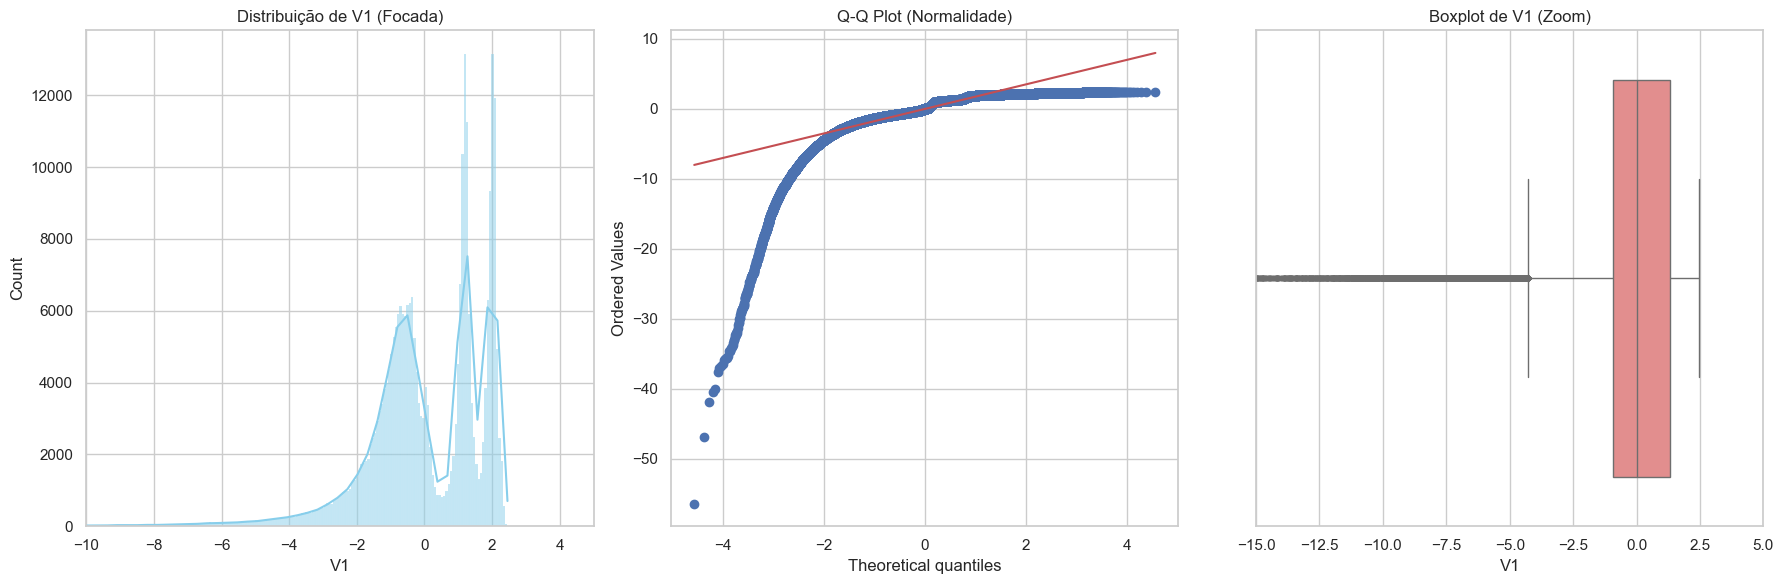

In [328]:
# selecao da feature
feature = 'V1' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    normal = 1 
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V1 comparada com classificacao


--- ANÁLISE DETALHADA E COMPARATIVA: V1 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.008258  0.020023  1.929814  284315
1             -4.771948 -2.342497  6.783687     492

[2] Índice de Separação pela mediana normalizada da V1: 1.21

[3] Feature consegue separar os grupos, com 1.74078470704578e-113 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V1 e status_fraude: -0.1013

[5] Correlação de spearman entre V1 e status_fraude: -0.0424

[6]Informação Mútua entre V1 e status_fraude: 0.0021

[7] Divergência KL (V1): 1.1726


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


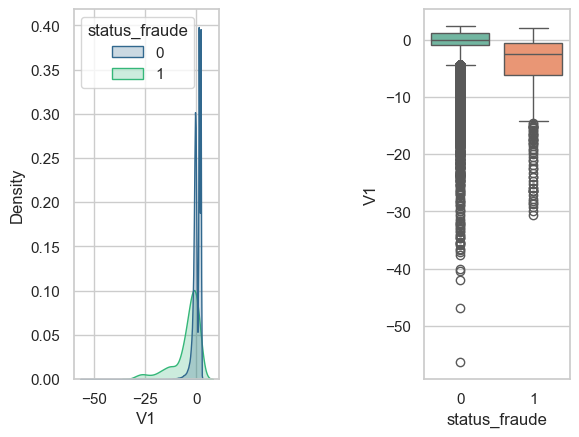

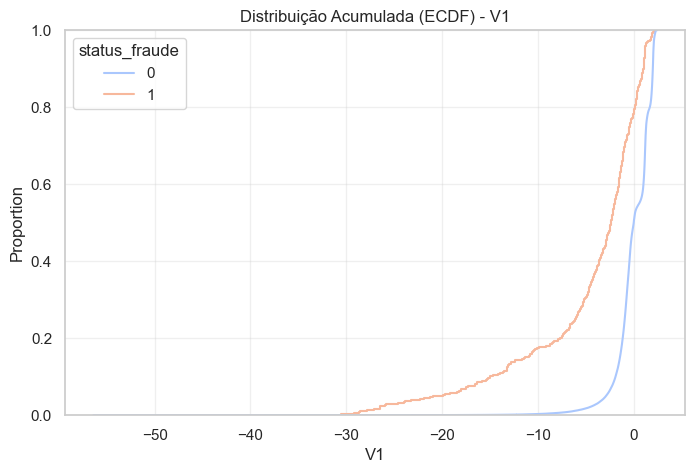

In [329]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v1 

In [330]:

resumo_features = []


In [331]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.20617,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595


### ESTUDO SOBRE V2

#### a) V2 descritiva 

--- ANÁLISE DETALHADA: V2 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     3.416908e-16
std      1.651309e+00
min     -7.271573e+01
25%     -5.985499e-01
50%      6.548556e-02
75%      8.037239e-01
max      2.205773e+01
Name: V2, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -4.62
Curtose (Kurtosis): 95.77

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V2: 0

[5] Entropia da feature V2: 0.1213

[6] A V2 carrega 8.87% da variabilidade total das componentes principais.

[7] A V2 possui 13526 outliers, representando um total de 4.7491810243428 %


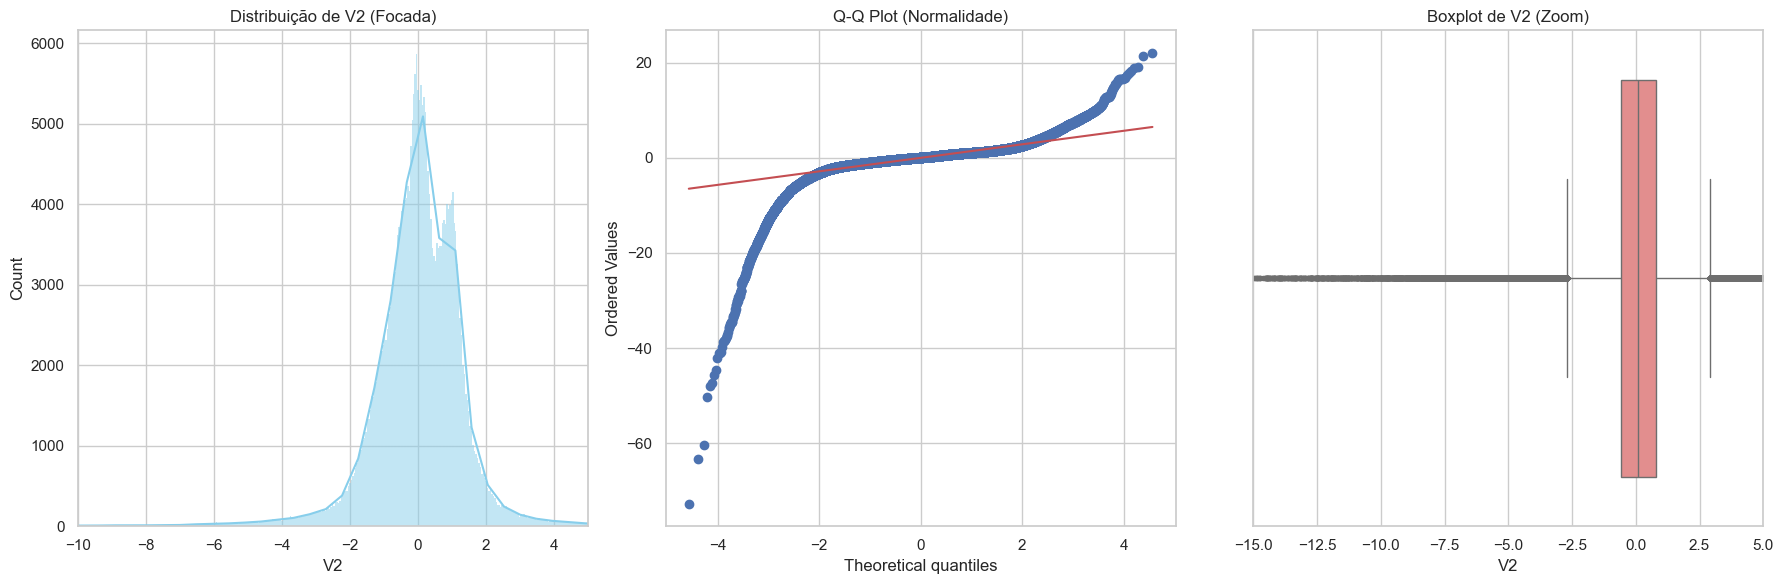

In [332]:
# selecao da feature
feature = 'V2' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V2 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V2 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.006271  0.064070  1.636146  284315
1              3.623778  2.717869  4.291216     492

[2] Índice de Separação pela mediana normalizada da V2: 1.61

[3] Feature consegue separar os grupos, com 1.6504376983790665e-163 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V2 e status_fraude: 0.0913

[5] Correlação de spearman entre V2 e status_fraude: 0.0511

[6]Informação Mútua entre V2 e status_fraude: 0.0032

[7] Divergência KL (V2): 5.4090


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


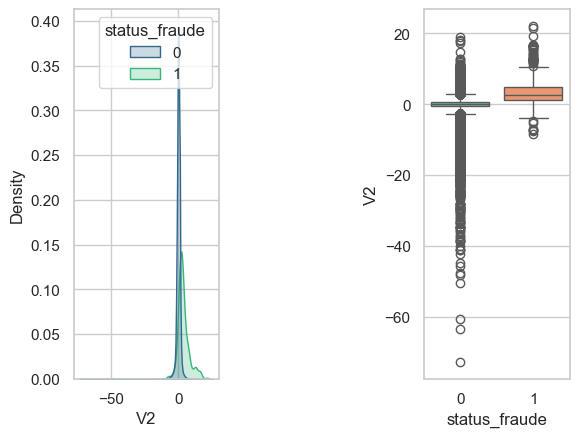

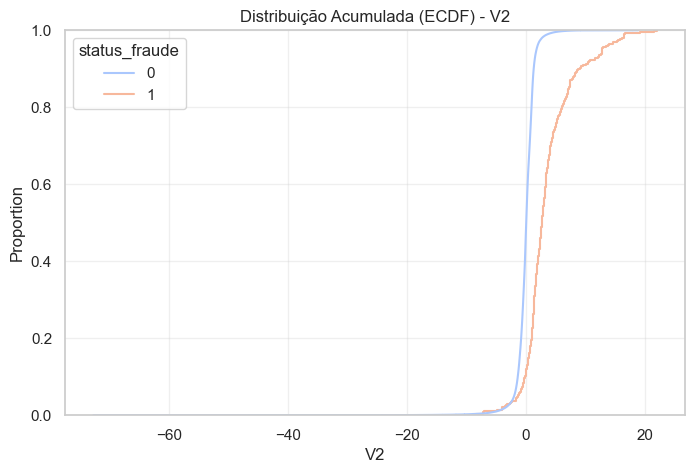

In [333]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v2


In [334]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018


### ESTUDO SOBRE V3

#### a) V3 descritiva 

--- ANÁLISE DETALHADA: V3 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -1.379537e-15
std      1.516255e+00
min     -4.832559e+01
25%     -8.903648e-01
50%      1.798463e-01
75%      1.027196e+00
max      9.382558e+00
Name: V3, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -2.24
Curtose (Kurtosis): 26.62

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V3: 0

[5] Entropia da feature V3: 0.2551

[6] A V3 carrega 7.48% da variabilidade total das componentes principais.

[7] A V3 possui 3363 outliers, representando um total de 1.1807996292225964 %


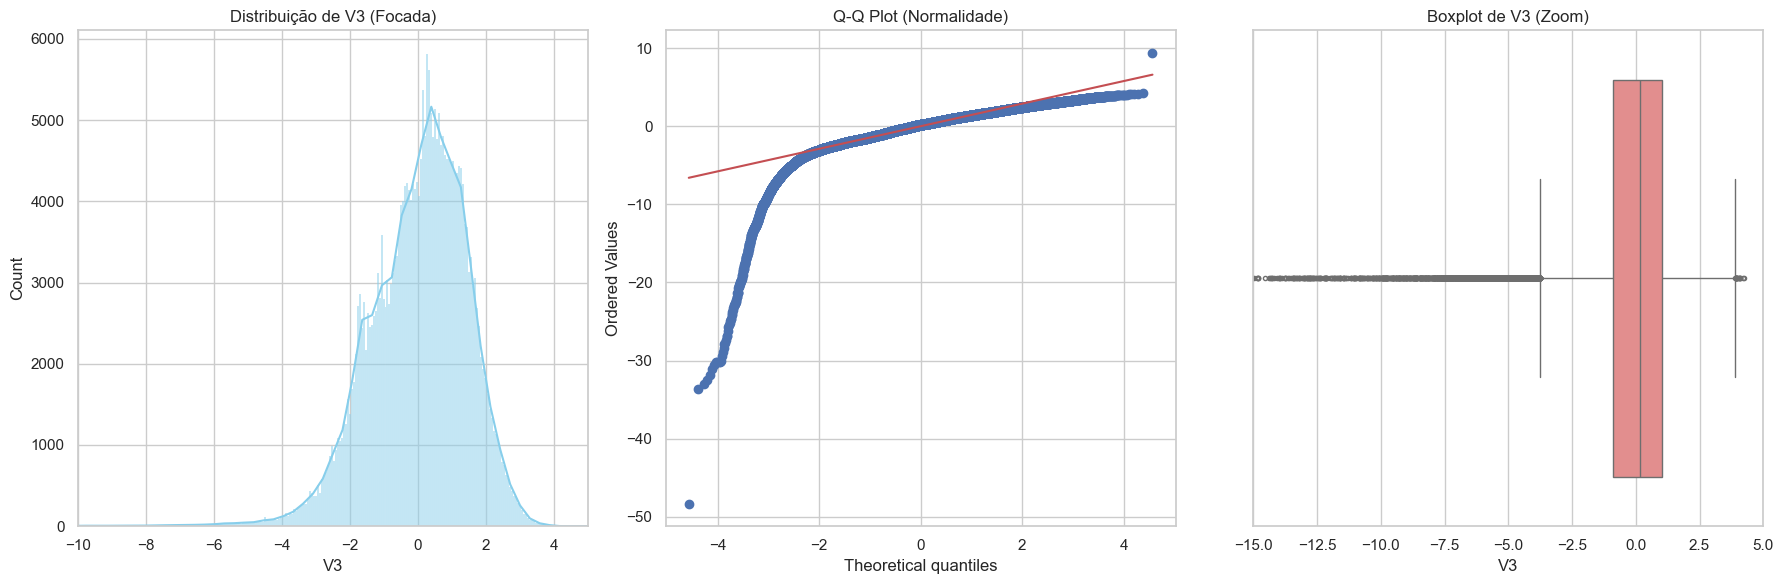

In [335]:
# selecao da feature
feature = 'V3' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V3 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V3 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.012171  0.182158  1.459429  284315
1             -7.033281 -5.075257  7.110937     492

[2] Índice de Separação pela mediana normalizada da V3: 3.47

[3] Feature consegue separar os grupos, com 1.2110480361161294e-219 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V3 e status_fraude: -0.1930

[5] Correlação de spearman entre V3 e status_fraude: -0.0593

[6]Informação Mútua entre V3 e status_fraude: 0.0050

[7] Divergência KL (V3): 1.2669


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


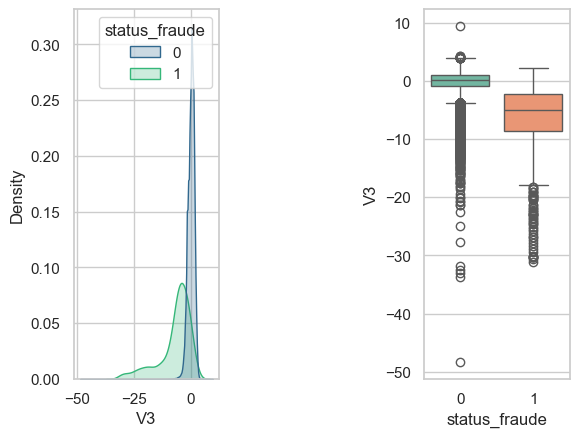

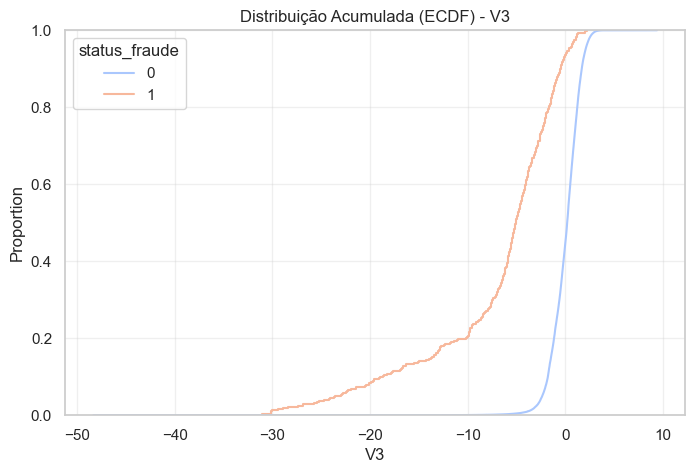

In [336]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v3


In [337]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913


### ESTUDO SOBRE V4

#### a) V4 descritiva 

--- ANÁLISE DETALHADA: V4 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     2.074095e-15
std      1.415869e+00
min     -5.683171e+00
25%     -8.486401e-01
50%     -1.984653e-02
75%      7.433413e-01
max      1.687534e+01
Name: V4, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 0.68
Curtose (Kurtosis): 2.64

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V4: 0

[5] Entropia da feature V4: 1.0133

[6] A V4 carrega 6.52% da variabilidade total das componentes principais.

[7] A V4 possui 11148 outliers, representando um total de 3.9142296362097846 %


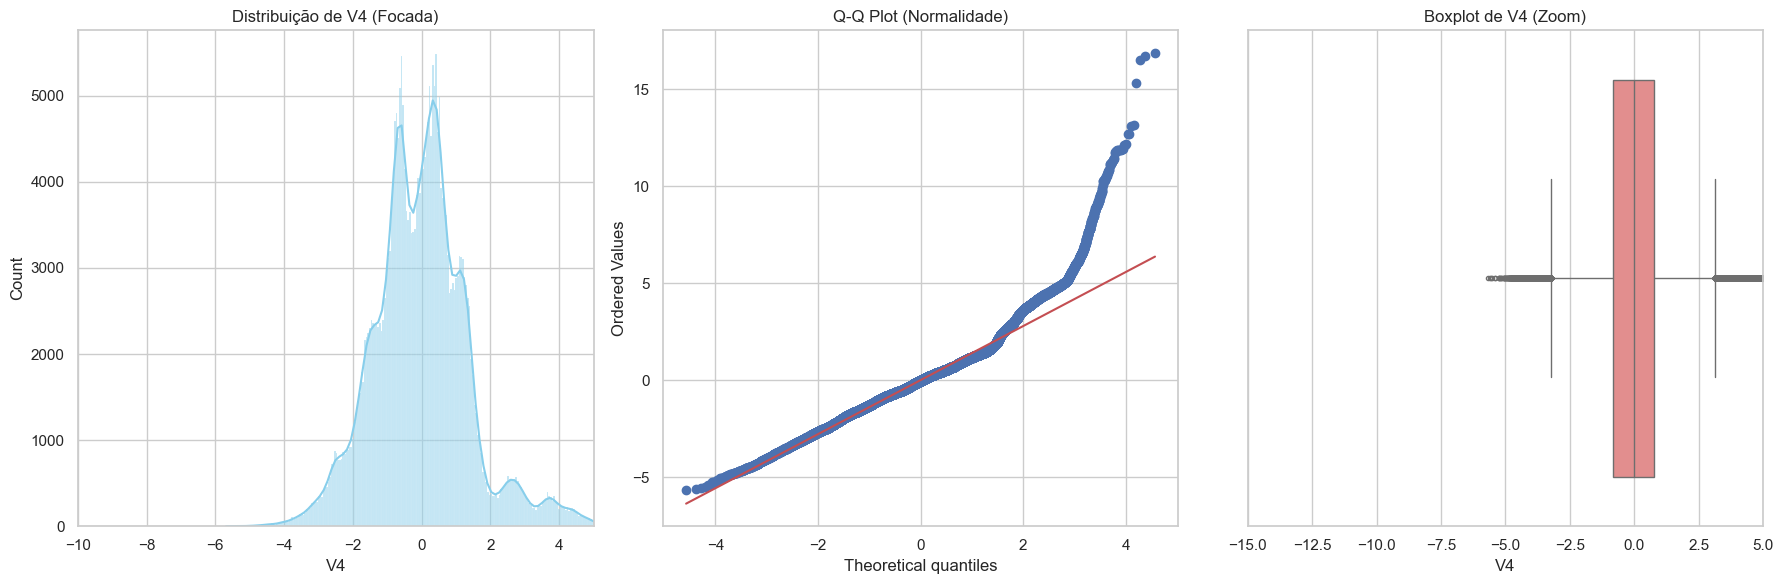

In [338]:
# selecao da feature
feature = 'V4' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V4 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V4 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.007860 -0.022405  1.399333  284315
1              4.542029  4.177147  2.873318     492

[2] Índice de Separação pela mediana normalizada da V4: 2.97

[3] Feature consegue separar os grupos, com 3.625904437063816e-248 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V4 e status_fraude: 0.1334

[5] Correlação de spearman entre V4 e status_fraude: 0.0630

[6]Informação Mútua entre V4 e status_fraude: 0.0050

[7] Divergência KL (V4): 0.9771


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


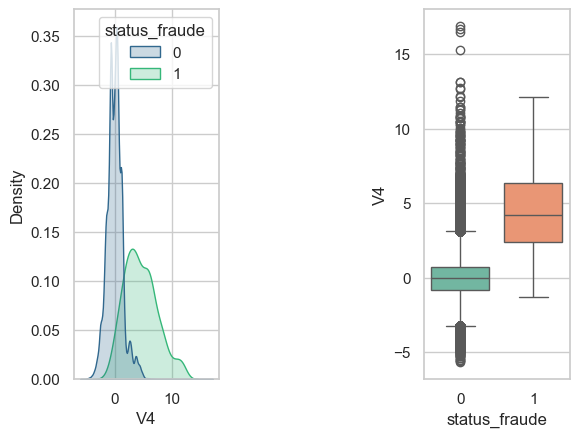

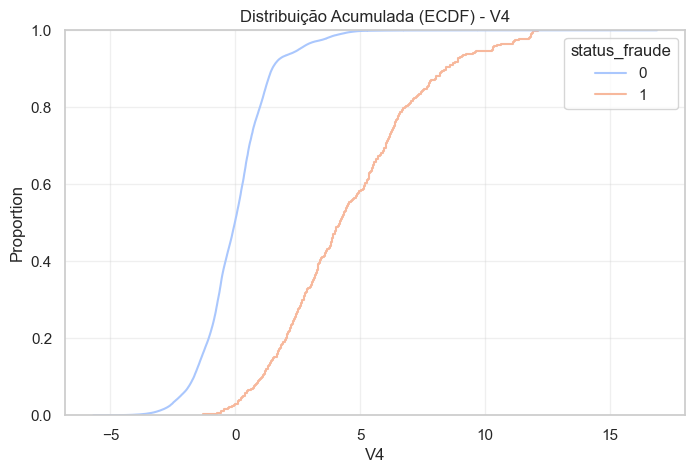

In [339]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v4

In [340]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064


### ESTUDO SOBRE V5

#### a) V5 descritiva 

--- ANÁLISE DETALHADA: V5 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     9.604066e-16
std      1.380247e+00
min     -1.137433e+02
25%     -6.915971e-01
50%     -5.433583e-02
75%      6.119264e-01
max      3.480167e+01
Name: V5, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -2.43
Curtose (Kurtosis): 206.90

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V5: 0

[5] Entropia da feature V5: 0.0275

[6] A V5 carrega 6.20% da variabilidade total das componentes principais.

[7] A V5 possui 12295 outliers, representando um total de 4.316958501722219 %


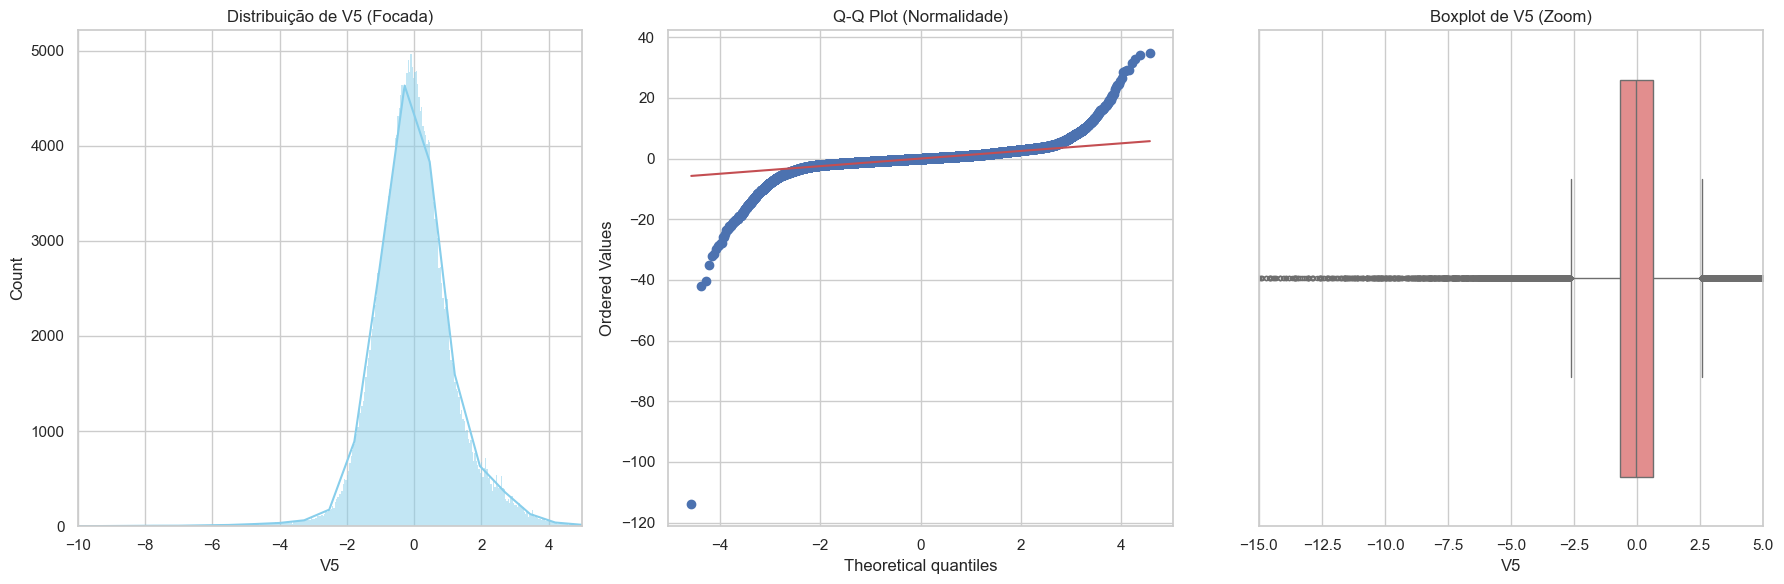

In [341]:
# selecao da feature
feature = 'V5' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V5 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V5 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.005453 -0.053457  1.356952  284315
1             -3.151225 -1.522962  5.372468     492

[2] Índice de Separação pela mediana normalizada da V5: 1.06

[3] Feature consegue separar os grupos, com 3.0537119618414104e-58 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V5 e status_fraude: -0.0950

[5] Correlação de spearman entre V5 e status_fraude: -0.0301

[6]Informação Mútua entre V5 e status_fraude: 0.0024

[7] Divergência KL (V5): 3.5111


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


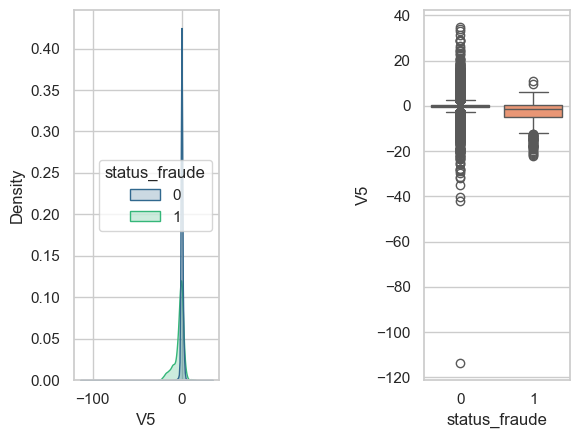

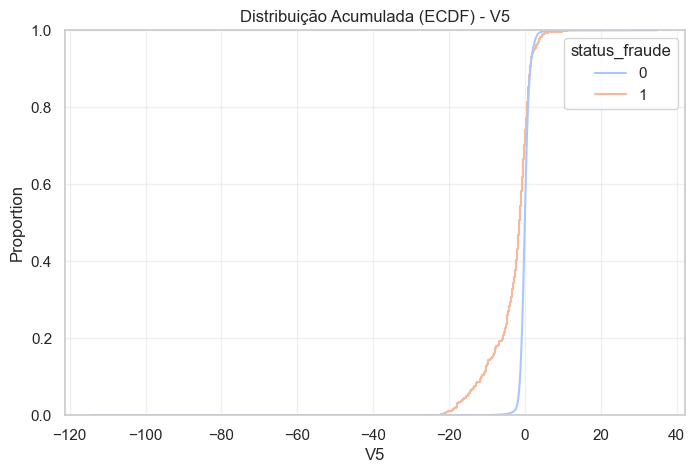

In [342]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v5

In [343]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113


### ESTUDO SOBRE V6

#### a) V6 descritiva 

--- ANÁLISE DETALHADA: V6 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.487313e-15
std      1.332271e+00
min     -2.616051e+01
25%     -7.682956e-01
50%     -2.741871e-01
75%      3.985649e-01
max      7.330163e+01
Name: V6, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 1.83
Curtose (Kurtosis): 42.64

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V6: 0

[5] Entropia da feature V6: 0.1201

[6] A V6 carrega 5.78% da variabilidade total das componentes principais.

[7] A V6 possui 22965 outliers, representando um total de 8.063355184388024 %


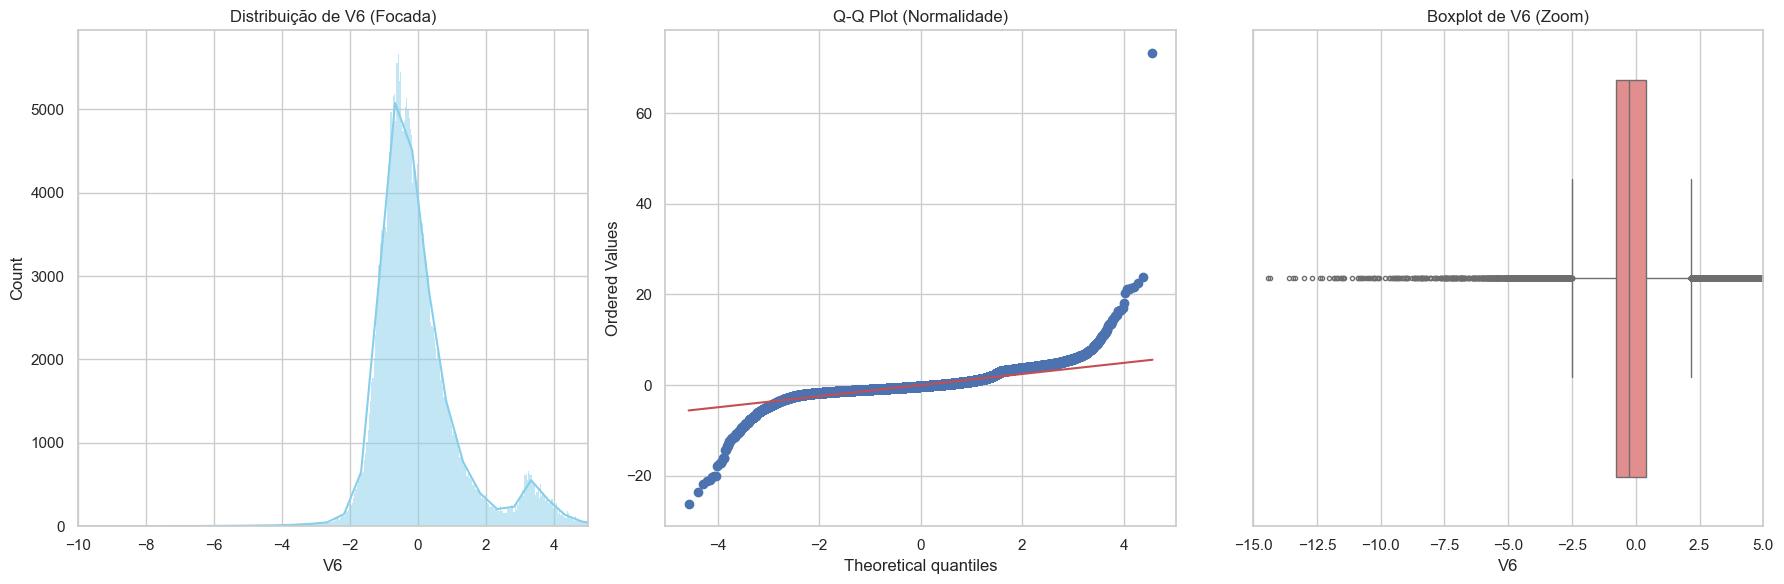

In [344]:
# selecao da feature
feature = 'V6' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V6 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V6 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.002419 -0.273123  1.329913  284315
1             -1.397737 -1.424616  1.858124     492

[2] Índice de Separação pela mediana normalizada da V6: 0.86

[3] Feature consegue separar os grupos, com 2.231002470170286e-93 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V6 e status_fraude: -0.0436

[5] Correlação de spearman entre V6 e status_fraude: -0.0384

[6]Informação Mútua entre V6 e status_fraude: 0.0024

[7] Divergência KL (V6): 2.2962


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


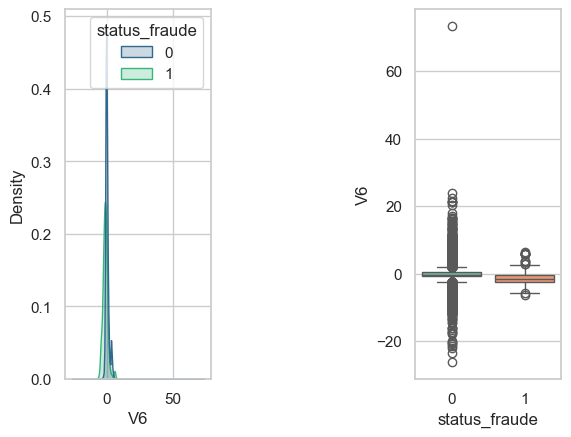

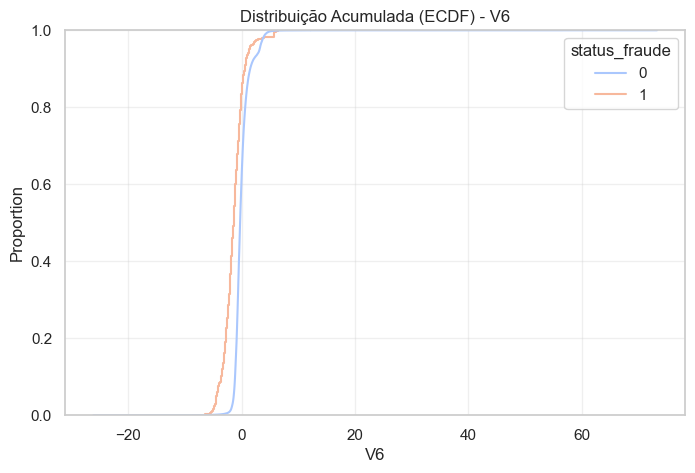

In [345]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v6

In [346]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178


### ESTUDO SOBRE V7

#### a) V7 descritiva 

--- ANÁLISE DETALHADA: V7 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -5.556467e-16
std      1.237094e+00
min     -4.355724e+01
25%     -5.540759e-01
50%      4.010308e-02
75%      5.704361e-01
max      1.205895e+02
Name: V7, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 2.55
Curtose (Kurtosis): 405.61

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V7: 0

[5] Entropia da feature V7: 0.0213

[6] A V7 carrega 4.98% da variabilidade total das componentes principais.

[7] A V7 possui 8948 outliers, representando um total de 3.1417767119487934 %


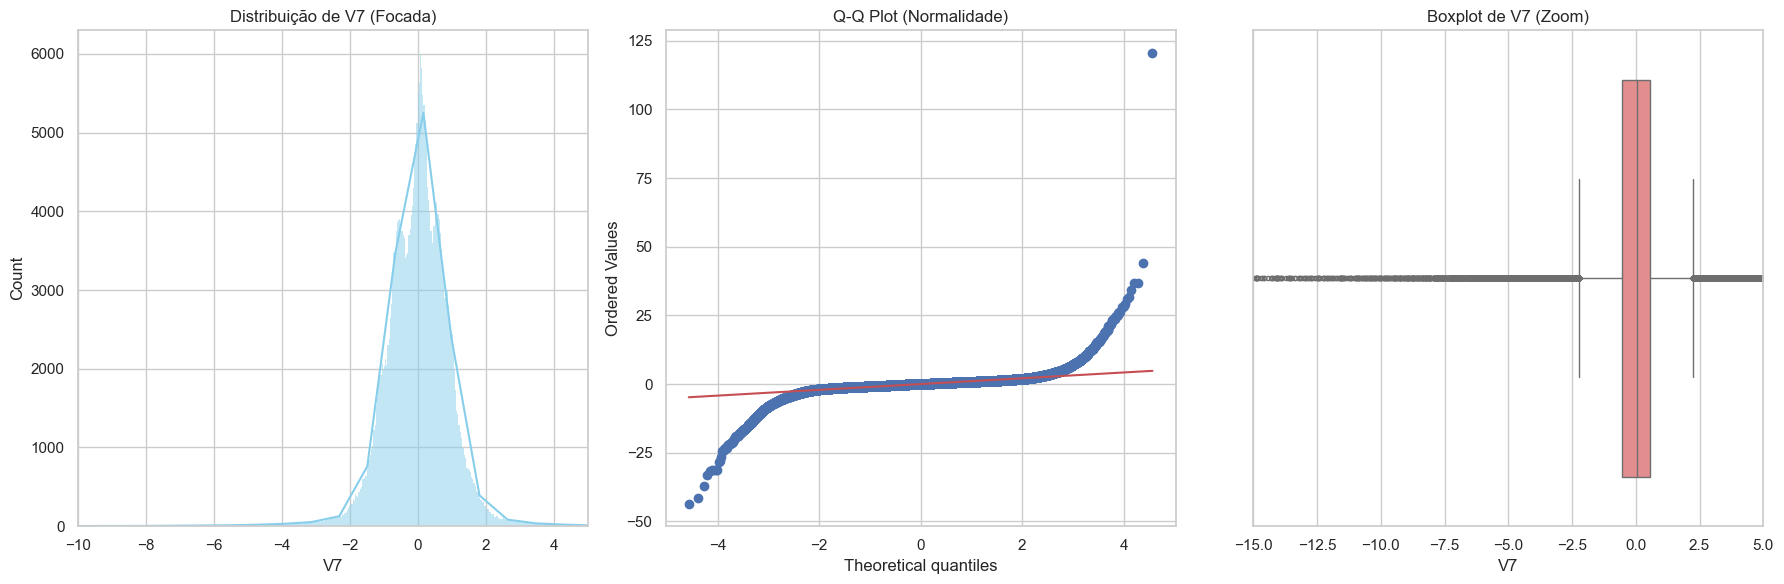

In [347]:
# selecao da feature
feature = 'V7' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V7 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V7 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.009637  0.041138  1.178812  284315
1             -5.568731 -3.034402  7.206773     492

[2] Índice de Separação pela mediana normalizada da V7: 2.49

[3] Feature consegue separar os grupos, com 1.4642336565270678e-146 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V7 e status_fraude: -0.1873

[5] Correlação de spearman entre V7 e status_fraude: -0.0483

[6]Informação Mútua entre V7 e status_fraude: 0.0040

[7] Divergência KL (V7): 7.2889


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


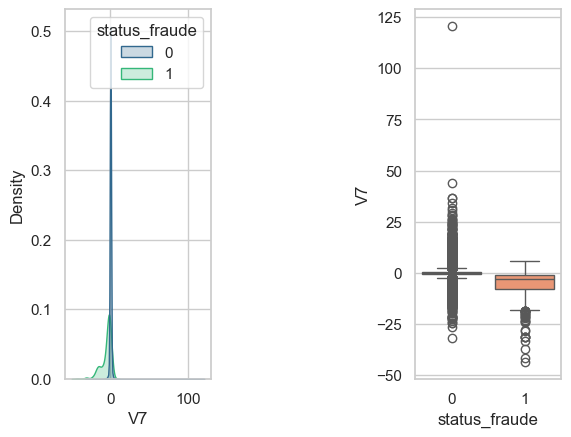

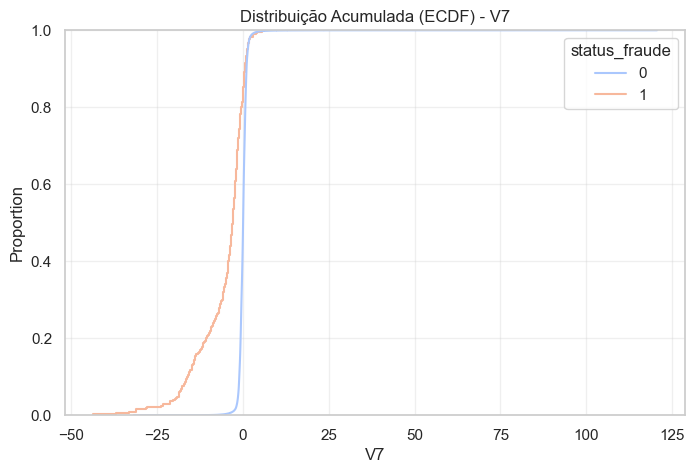

In [348]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v7

In [349]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937


### ESTUDO SOBRE V8

#### a) V8 descritiva 

--- ANÁLISE DETALHADA: V8 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.213481e-16
std      1.194353e+00
min     -7.321672e+01
25%     -2.086297e-01
50%      2.235804e-02
75%      3.273459e-01
max      2.000721e+01
Name: V8, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -8.52
Curtose (Kurtosis): 220.59

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V8: 0

[5] Entropia da feature V8: 0.1453

[6] A V8 carrega 4.64% da variabilidade total das componentes principais.

[7] A V8 possui 24134 outliers, representando um total de 8.47380857914307 %


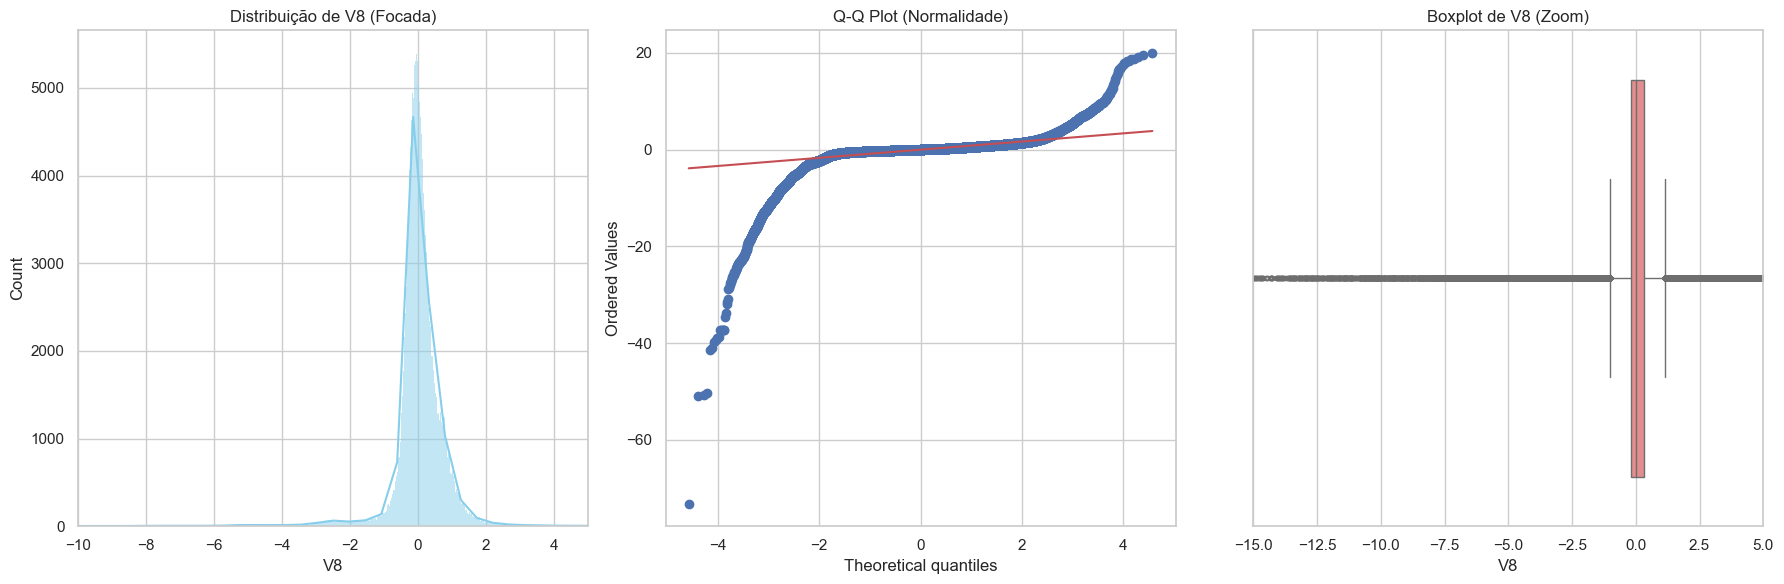

In [350]:
# selecao da feature
feature = 'V8' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V8 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V8 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000987  0.022041  1.161283  284315
1              0.570636  0.621508  6.797831     492

[2] Índice de Separação pela mediana normalizada da V8: 0.50

[3] Feature consegue separar os grupos, com 8.50989149282899e-34 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V8 e status_fraude: 0.0199

[5] Correlação de spearman entre V8 e status_fraude: 0.0227

[6]Informação Mútua entre V8 e status_fraude: 0.0019

[7] Divergência KL (V8): 3.1351


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


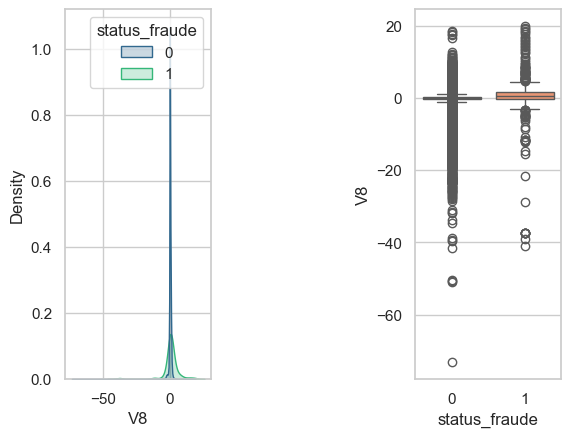

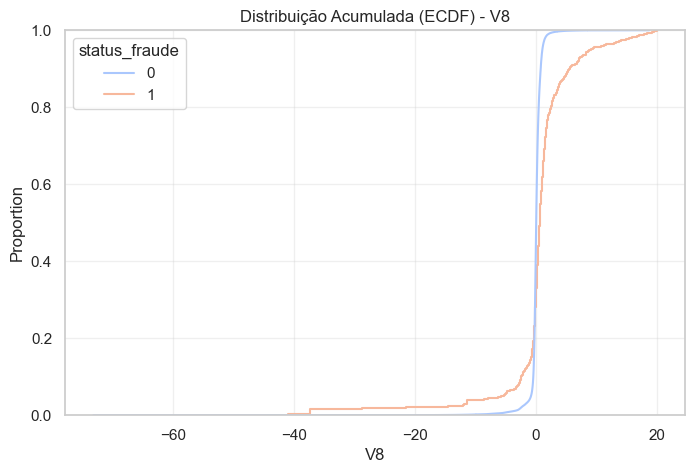

In [351]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v8

In [352]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096


### ESTUDO SOBRE V9

#### a) V9 descritiva 

--- ANÁLISE DETALHADA: V9 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -2.406331e-15
std      1.098632e+00
min     -1.343407e+01
25%     -6.430976e-01
50%     -5.142873e-02
75%      5.971390e-01
max      1.559499e+01
Name: V9, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 0.55
Curtose (Kurtosis): 3.73

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V9: 0

[5] Entropia da feature V9: 0.6000

[6] A V9 carrega 3.93% da variabilidade total das componentes principais.

[7] A V9 possui 8283 outliers, representando um total de 2.9082852598426303 %


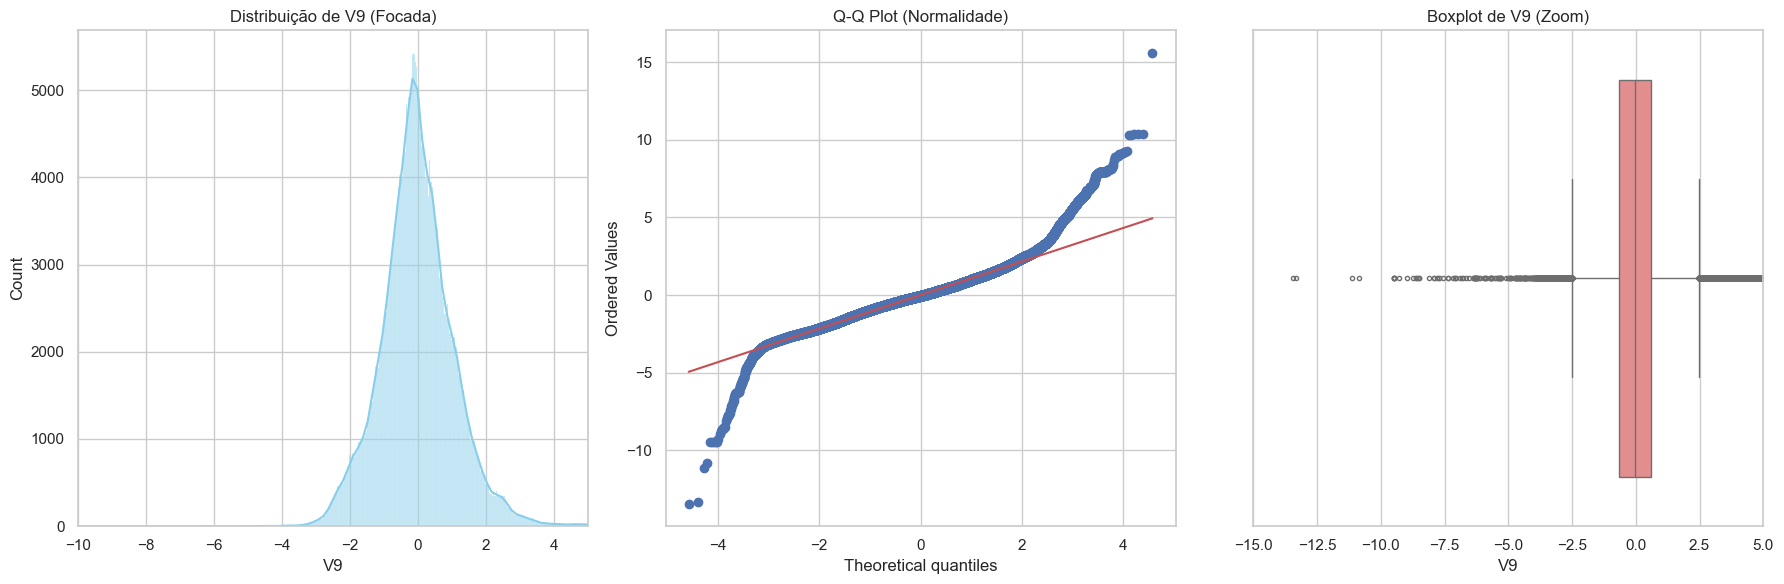

In [353]:
# selecao da feature
feature = 'V9' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V9 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V9 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.004467 -0.049964  1.089372  284315
1             -2.581123 -2.208768  2.500896     492

[2] Índice de Separação pela mediana normalizada da V9: 1.96

[3] Feature consegue separar os grupos, com 8.943723386517164e-154 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V9 e status_fraude: -0.0977

[5] Correlação de spearman entre V9 e status_fraude: -0.0495

[6]Informação Mútua entre V9 e status_fraude: 0.0043

[7] Divergência KL (V9): 4.3915


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


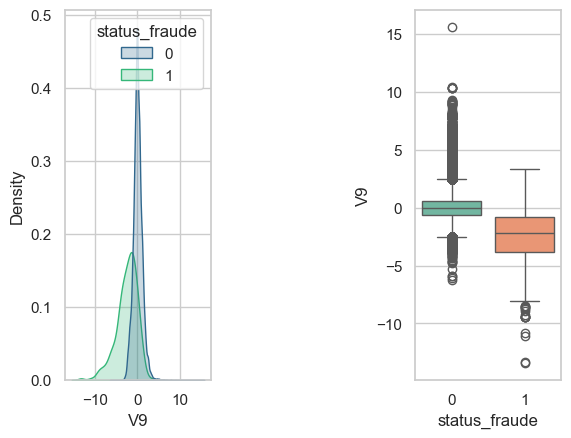

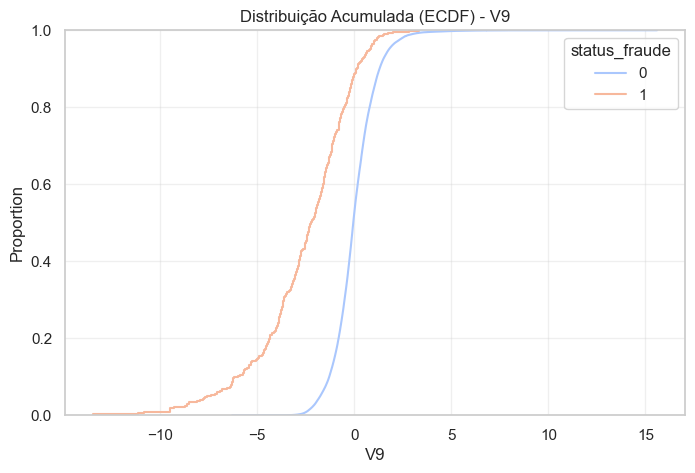

In [354]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v9

In [355]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476


### ESTUDO SOBRE V10

#### a) V10 descritiva 

--- ANÁLISE DETALHADA: V10 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     2.239053e-15
std      1.088850e+00
min     -2.458826e+01
25%     -5.354257e-01
50%     -9.291738e-02
75%      4.539234e-01
max      2.374514e+01
Name: V10, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 1.19
Curtose (Kurtosis): 31.99

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V10: 0

[5] Entropia da feature V10: 0.6582

[6] A V10 carrega 3.86% da variabilidade total das componentes principais.

[7] A V10 possui 9496 outliers, representando um total de 3.334187713082895 %


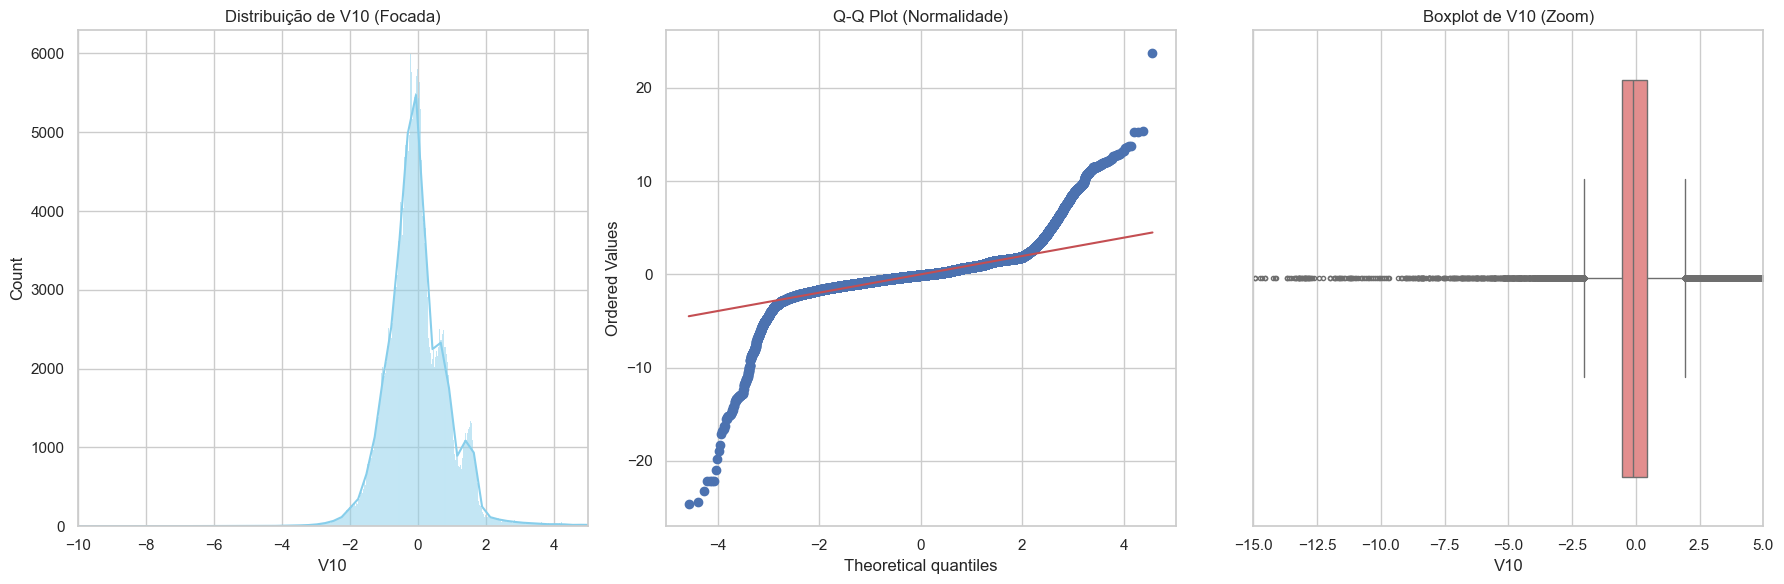

In [356]:
# selecao da feature
feature = 'V10' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V10 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V10 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.009824 -0.091872  1.044204  284315
1             -5.676883 -4.578825  4.897341     492

[2] Índice de Separação pela mediana normalizada da V10: 4.12

[3] Feature consegue separar os grupos, com 9.611130933483015e-222 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V10 e status_fraude: -0.2169

[5] Correlação de spearman entre V10 e status_fraude: -0.0596

[6]Informação Mútua entre V10 e status_fraude: 0.0075

[7] Divergência KL (V10): 2.8064


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


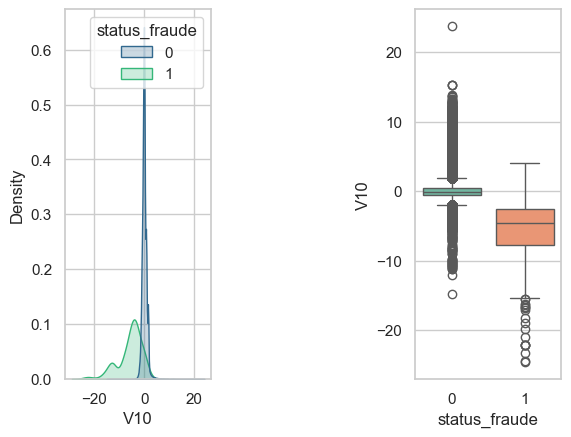

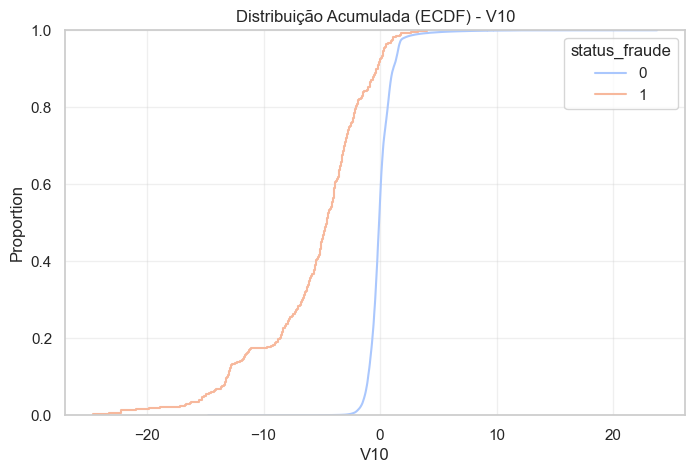

In [357]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v10

In [358]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V11

#### a) V11 descritiva 

--- ANÁLISE DETALHADA: V11 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.673327e-15
std      1.020713e+00
min     -4.797473e+00
25%     -7.624942e-01
50%     -3.275735e-02
75%      7.395934e-01
max      1.201891e+01
Name: V11, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 0.36
Curtose (Kurtosis): 1.63

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V11: 0

[5] Entropia da feature V11: 0.9870

[6] A V11 carrega 3.39% da variabilidade total das componentes principais.

[7] A V11 possui 780 outliers, representando um total de 0.27386967314707855 %


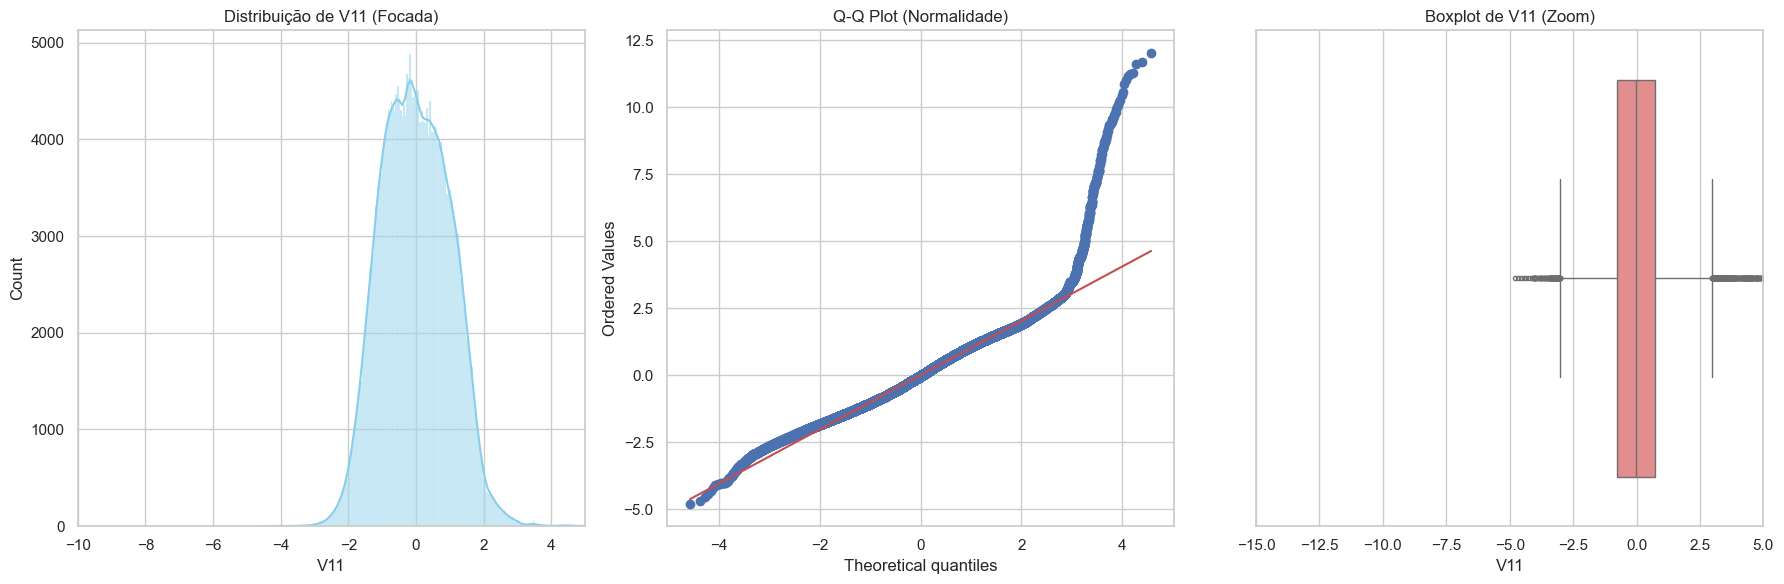

In [359]:
# selecao da feature
feature = 'V11' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V11 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V11 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.006576 -0.034923  1.003112  284315
1              3.800173  3.586218  2.678605     492

[2] Índice de Separação pela mediana normalizada da V11: 3.55

[3] Feature consegue separar os grupos, com 4.910591830672246e-226 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V11 e status_fraude: 0.1549

[5] Correlação de spearman entre V11 e status_fraude: 0.0601

[6]Informação Mútua entre V11 e status_fraude: 0.0068

[7] Divergência KL (V11): 0.6560


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


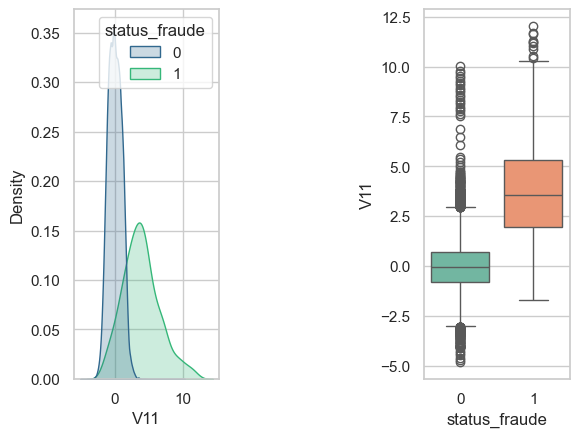

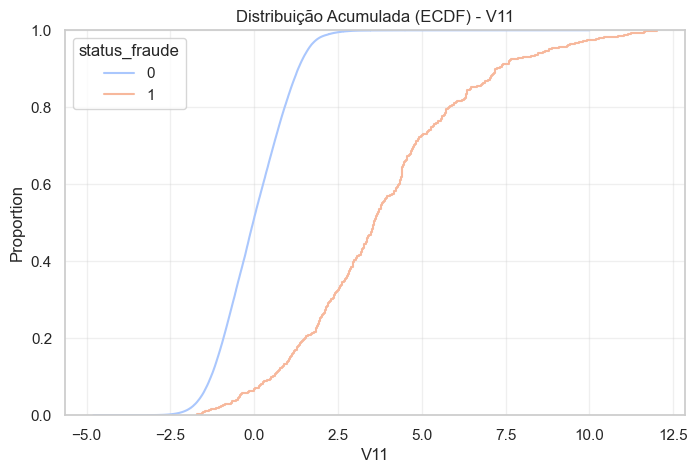

In [360]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v11

In [361]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V12

#### a) V12 descritiva 

--- ANÁLISE DETALHADA: V12 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -1.247012e-15
std      9.992014e-01
min     -1.868371e+01
25%     -4.055715e-01
50%      1.400326e-01
75%      6.182380e-01
max      7.848392e+00
Name: V12, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -2.28
Curtose (Kurtosis): 20.24

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V12: 0

[5] Entropia da feature V12: 0.7441

[6] A V12 carrega 3.25% da variabilidade total das componentes principais.

[7] A V12 possui 15348 outliers, representando um total de 5.3889124916171305 %


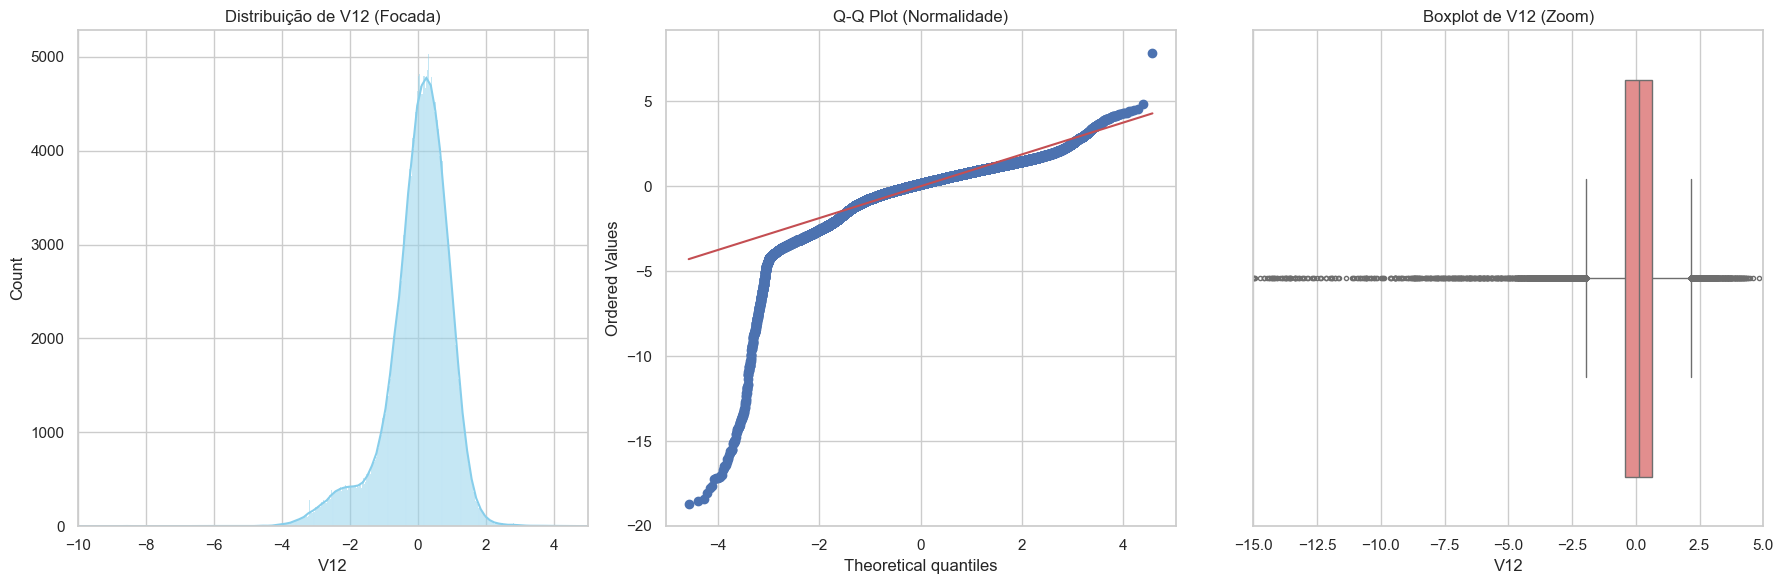

In [362]:
# selecao da feature
feature = 'V12' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V12 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V12 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.010832  0.141679  0.945939  284315
1             -6.259393 -5.502530  4.654458     492

[2] Índice de Separação pela mediana normalizada da V12: 5.65

[3] Feature consegue separar os grupos, com 8.416026601180421e-247 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V12 e status_fraude: -0.2606

[5] Correlação de spearman entre V12 e status_fraude: -0.0629

[6]Informação Mútua entre V12 e status_fraude: 0.0076

[7] Divergência KL (V12): 1.3214


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


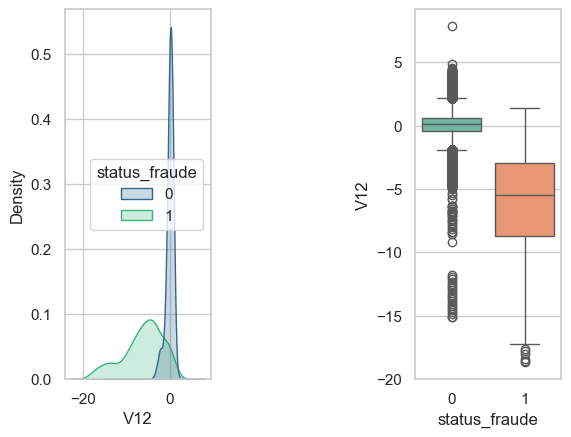

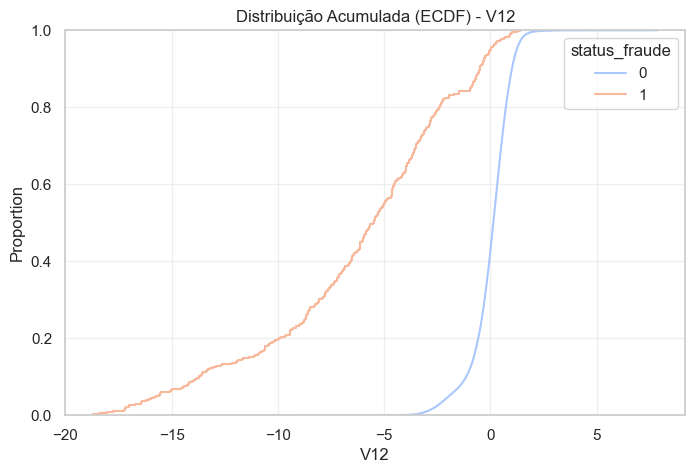

In [363]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v12

In [364]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V13

#### a) V13 descritiva 

--- ANÁLISE DETALHADA: V13 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     8.190001e-16
std      9.952742e-01
min     -5.791881e+00
25%     -6.485393e-01
50%     -1.356806e-02
75%      6.625050e-01
max      7.126883e+00
Name: V13, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 0.07
Curtose (Kurtosis): 0.20

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V13: 0

[5] Entropia da feature V13: 1.2187

[6] A V13 carrega 3.22% da variabilidade total das componentes principais.

[7] A V13 possui 3368 outliers, representando um total de 1.182555204050462 %


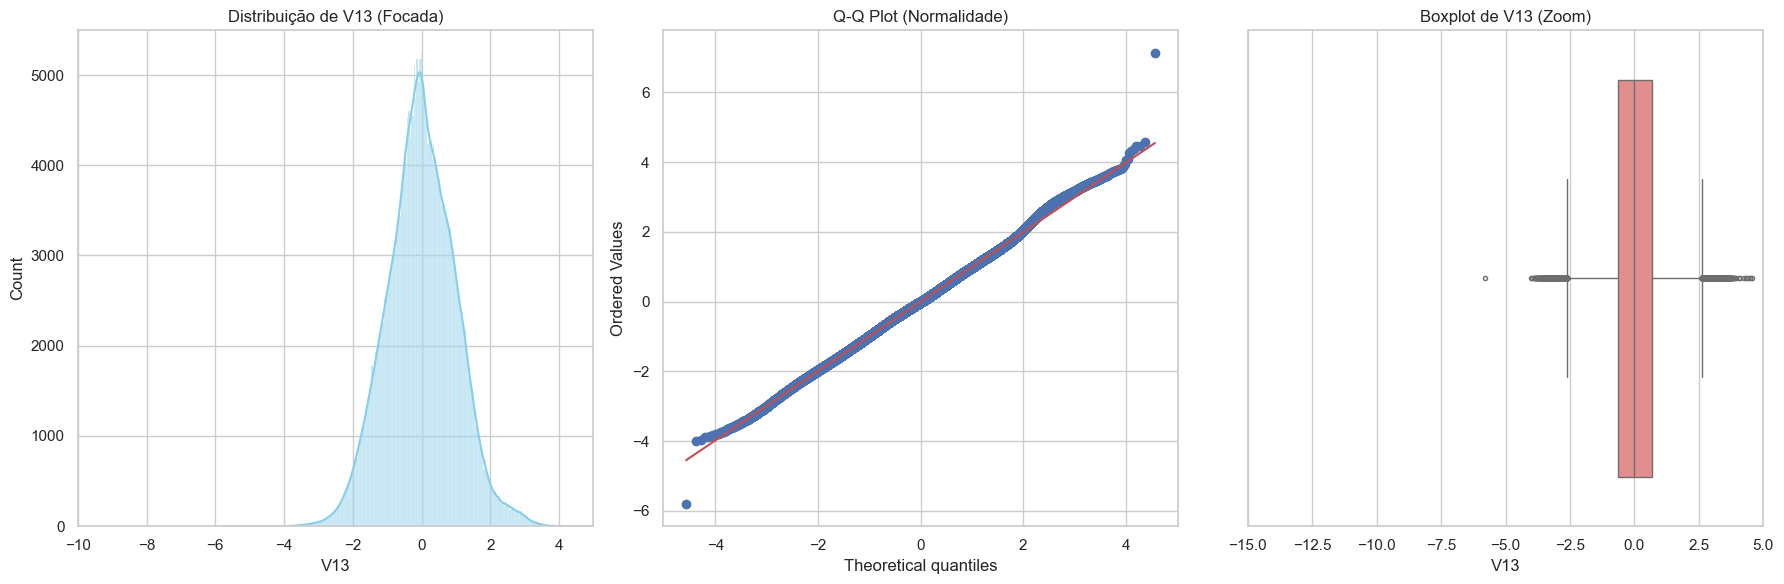

In [365]:
# selecao da feature
feature = 'V13' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V13 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V13 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.000189 -0.013547  0.995067  284315
1             -0.109334 -0.065566  1.104518     492

[2] Índice de Separação pela mediana normalizada da V13: 0.05

[3] feature não consegue separar os grupos, com 0.051214811167866046 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V13 e status_fraude: -0.0046

[5] Correlação de spearman entre V13 e status_fraude: -0.0037

[6]Informação Mútua entre V13 e status_fraude: 0.0004

[7] Divergência KL (V13): 0.6699


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


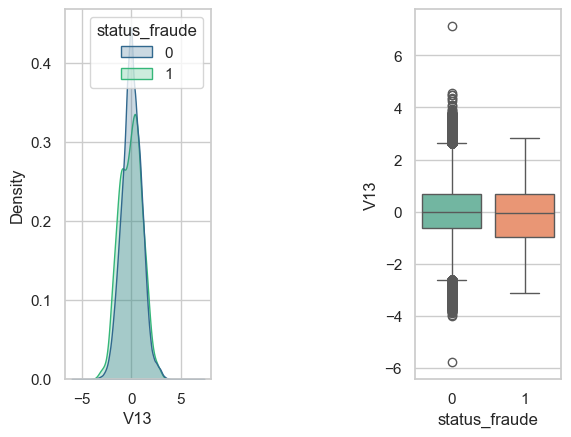

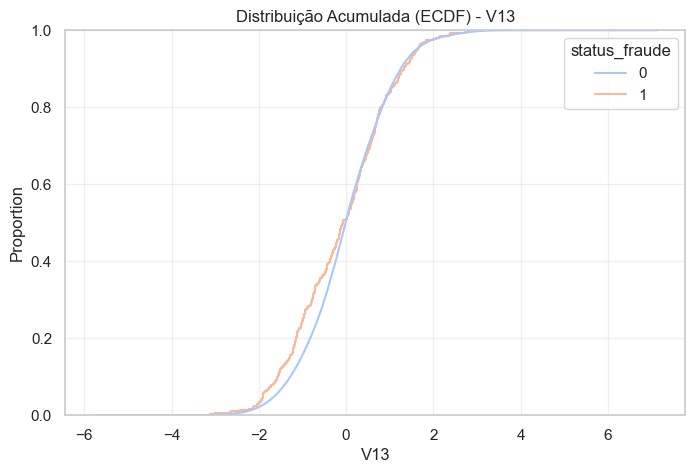

In [366]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v13

In [367]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V14

#### a) V14 descritiva 

--- ANÁLISE DETALHADA: V14 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.207294e-15
std      9.585956e-01
min     -1.921433e+01
25%     -4.255740e-01
50%      5.060132e-02
75%      4.931498e-01
max      1.052677e+01
Name: V14, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -2.00
Curtose (Kurtosis): 23.88

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V14: 0

[5] Entropia da feature V14: 0.3753

[6] A V14 carrega 2.99% da variabilidade total das componentes principais.

[7] A V14 possui 14149 outliers, representando um total de 4.96792564789489 %


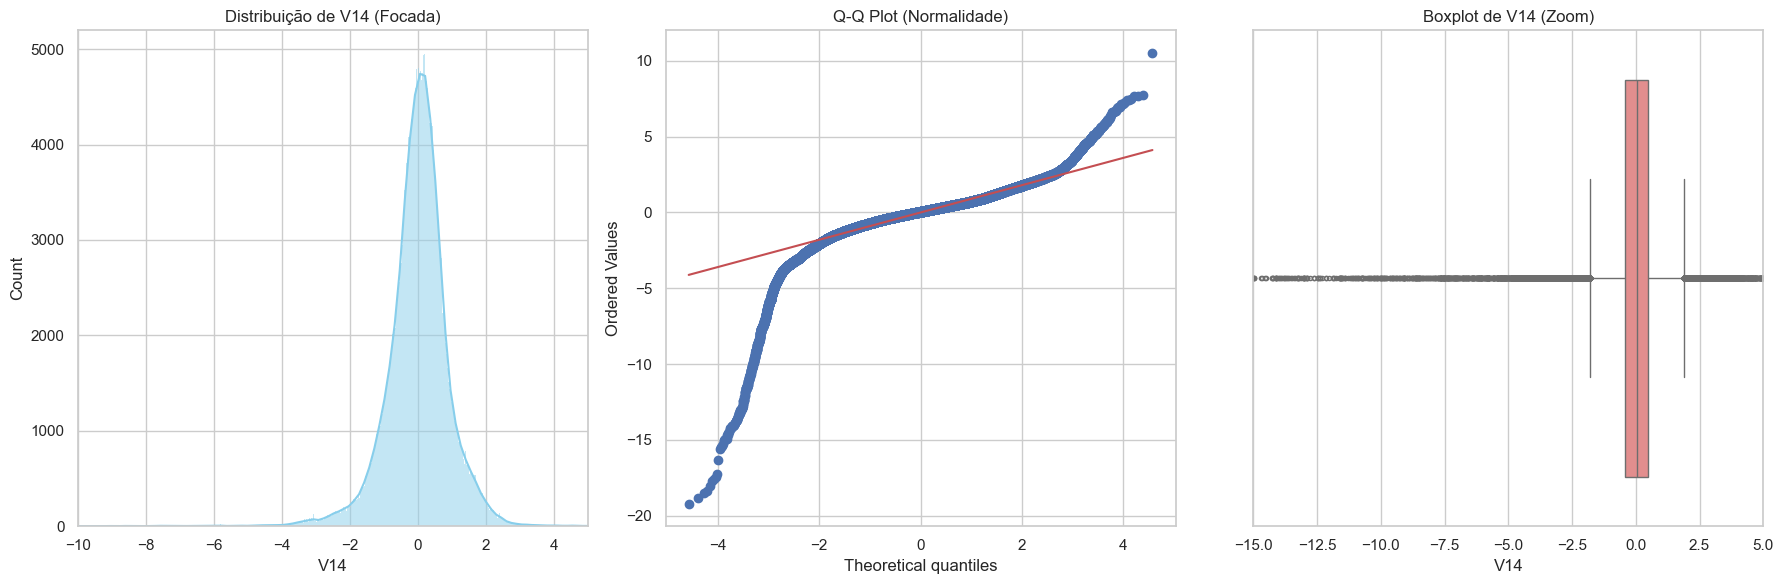

In [368]:
# selecao da feature
feature = 'V14' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V14 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V14 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.012064  0.051947  0.897007  284315
1             -6.971723 -6.729720  4.278940     492

[2] Índice de Separação pela mediana normalizada da V14: 7.07

[3] Feature consegue separar os grupos, com 1.4715806820794069e-260 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V14 e status_fraude: -0.3025

[5] Correlação de spearman entre V14 e status_fraude: -0.0646

[6]Informação Mútua entre V14 e status_fraude: 0.0081

[7] Divergência KL (V14): 1.2903


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


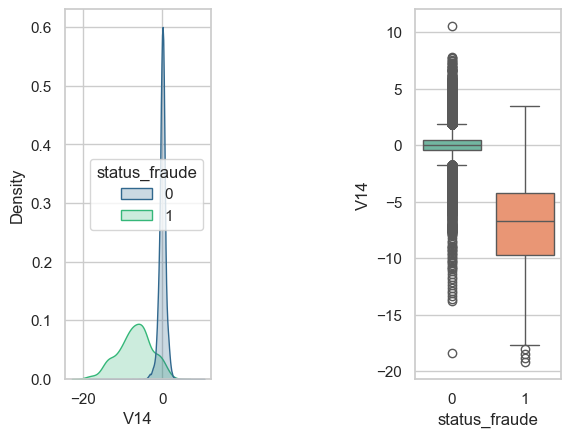

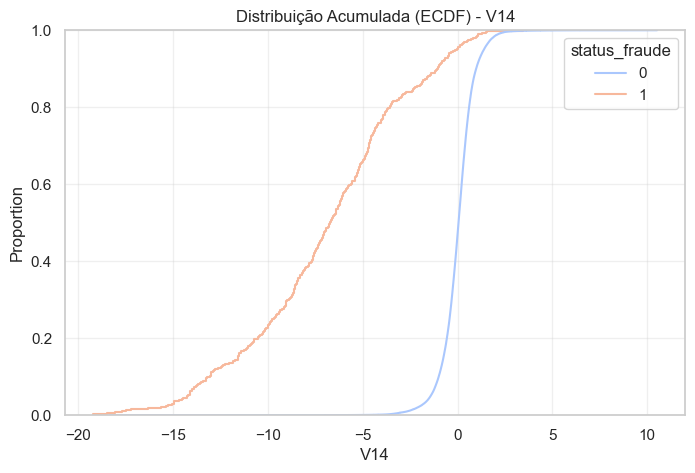

In [369]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v14

In [370]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V15

#### a) V15 descritiva 

--- ANÁLISE DETALHADA: V15 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     4.887456e-15
std      9.153160e-01
min     -4.498945e+00
25%     -5.828843e-01
50%      4.807155e-02
75%      6.488208e-01
max      8.877742e+00
Name: V15, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -0.31
Curtose (Kurtosis): 0.28

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V15: 0

[5] Entropia da feature V15: 1.1289

[6] A V15 carrega 2.73% da variabilidade total das componentes principais.

[7] A V15 possui 2894 outliers, representando um total de 1.0161267103687759 %


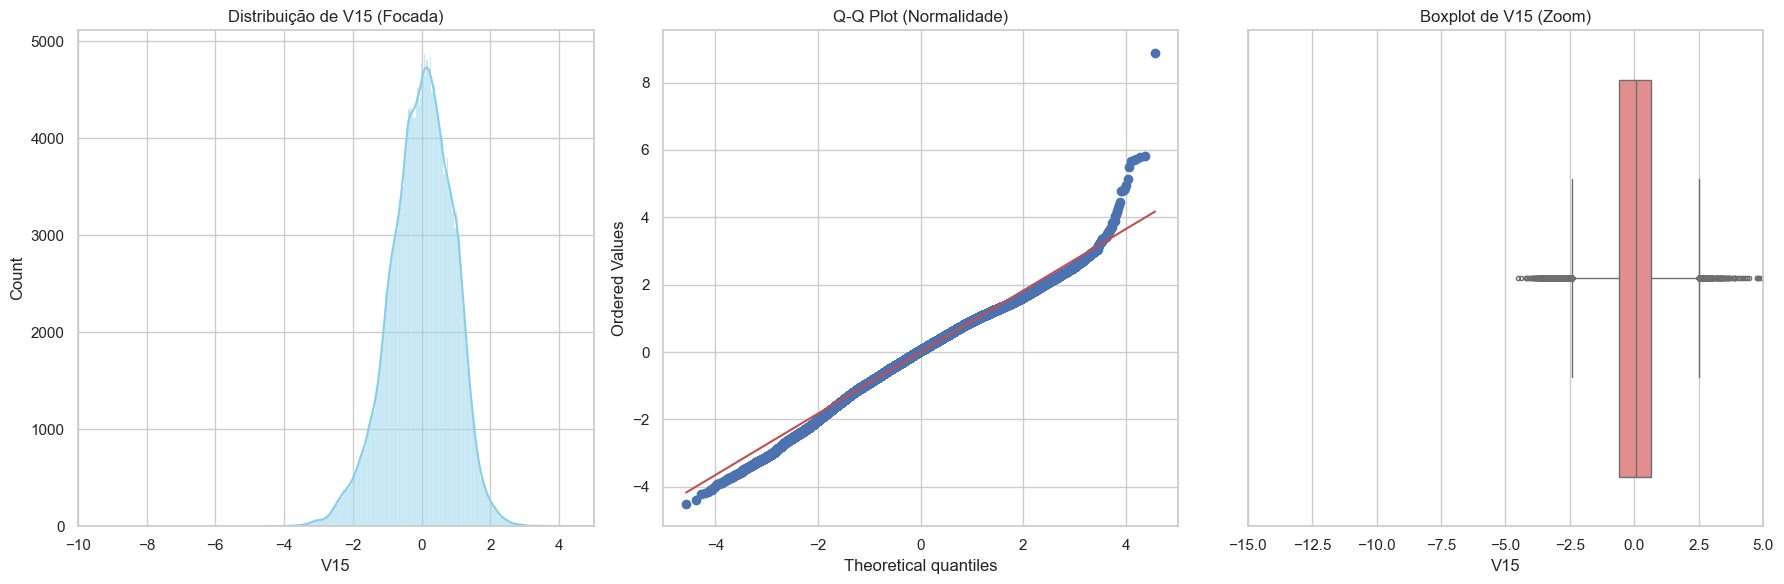

In [371]:
# selecao da feature
feature = 'V15' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V15 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V15 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.000161  0.048294  0.915060  284315
1             -0.092929 -0.057227  1.049915     492

[2] Índice de Separação pela mediana normalizada da V15: 0.12

[3] feature não consegue separar os grupos, com 0.12950821497825638 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V15 e status_fraude: -0.0042

[5] Correlação de spearman entre V15 e status_fraude: -0.0028

[6]Informação Mútua entre V15 e status_fraude: 0.0003

[7] Divergência KL (V15): 4.2222


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


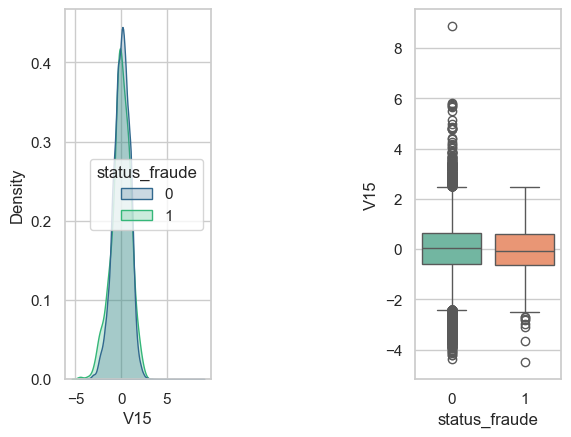

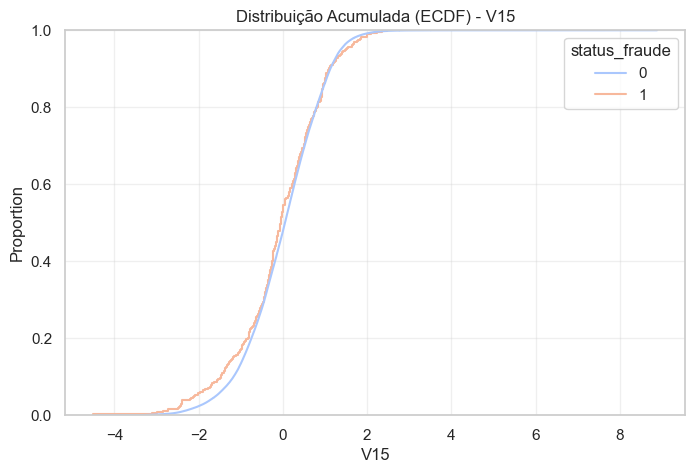

In [372]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v15

In [373]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V16

#### a) V16 descritiva 

--- ANÁLISE DETALHADA: V16 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.437716e-15
std      8.762529e-01
min     -1.412985e+01
25%     -4.680368e-01
50%      6.641332e-02
75%      5.232963e-01
max      1.731511e+01
Name: V16, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -1.10
Curtose (Kurtosis): 10.42

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V16: 0

[5] Entropia da feature V16: 0.3061

[6] A V16 carrega 2.50% da variabilidade total das componentes principais.

[7] A V16 possui 8184 outliers, representando um total de 2.873524878250886 %


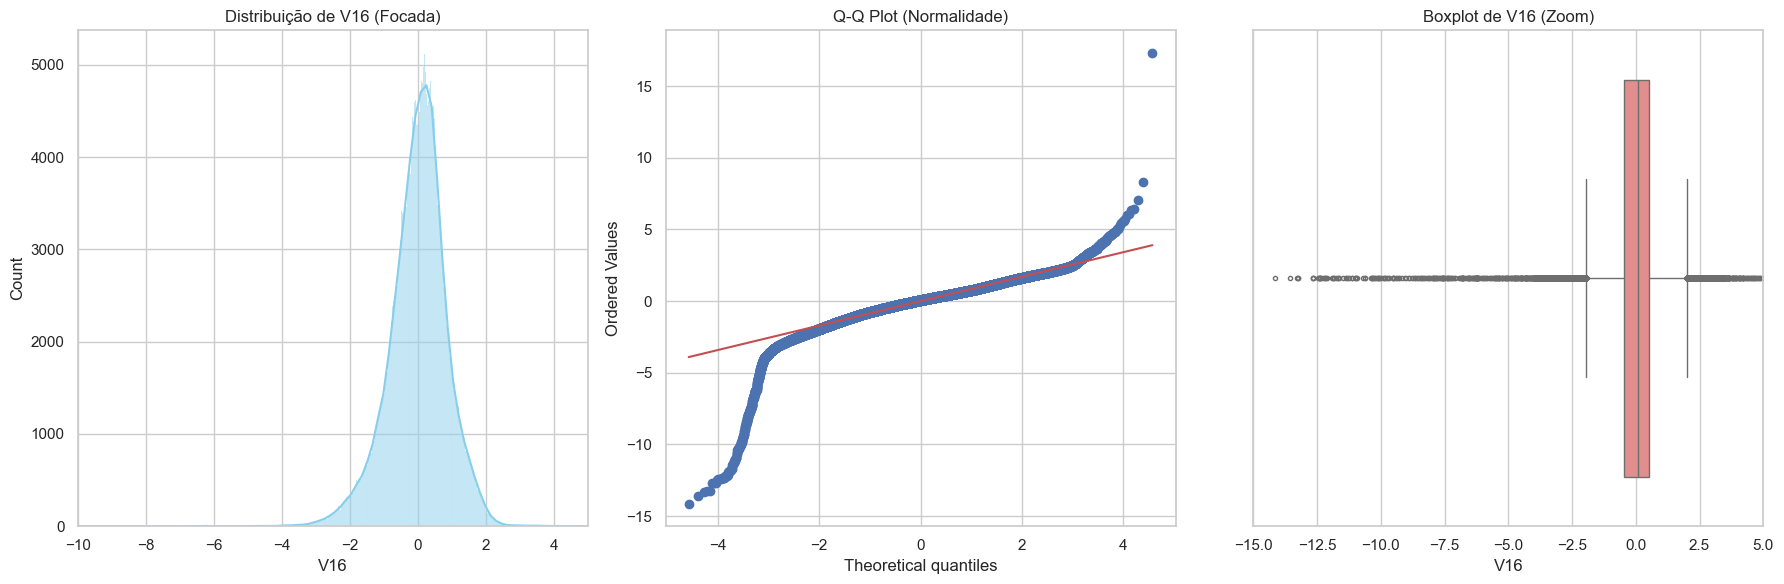

In [374]:
# selecao da feature
feature = 'V16' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V16 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V16 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.007164  0.067377  0.844772  284315
1             -4.139946 -3.549795  3.865035     492

[2] Índice de Separação pela mediana normalizada da V16: 4.13

[3] Feature consegue separar os grupos, com 1.8081722832035591e-156 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V16 e status_fraude: -0.1965

[5] Correlação de spearman entre V16 e status_fraude: -0.0499

[6]Informação Mútua entre V16 e status_fraude: 0.0061

[7] Divergência KL (V16): 2.2289


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


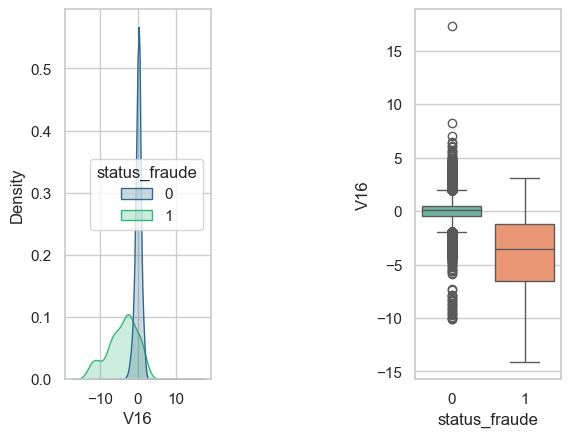

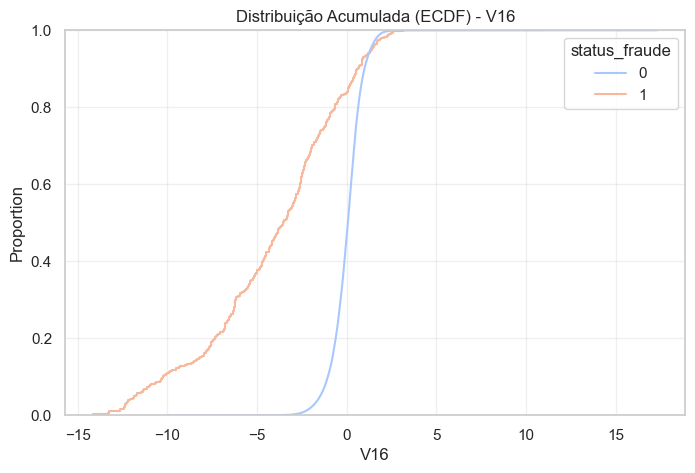

In [375]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v16

In [376]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V17

#### a) V17 descritiva 

--- ANÁLISE DETALHADA: V17 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -3.772171e-16
std      8.493371e-01
min     -2.516280e+01
25%     -4.837483e-01
50%     -6.567575e-02
75%      3.996750e-01
max      9.253526e+00
Name: V17, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -3.84
Curtose (Kurtosis): 94.80

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V17: 0

[5] Entropia da feature V17: 0.2106

[6] A V17 carrega 2.35% da variabilidade total das componentes principais.

[7] A V17 possui 7420 outliers, representando um total de 2.605273044552978 %


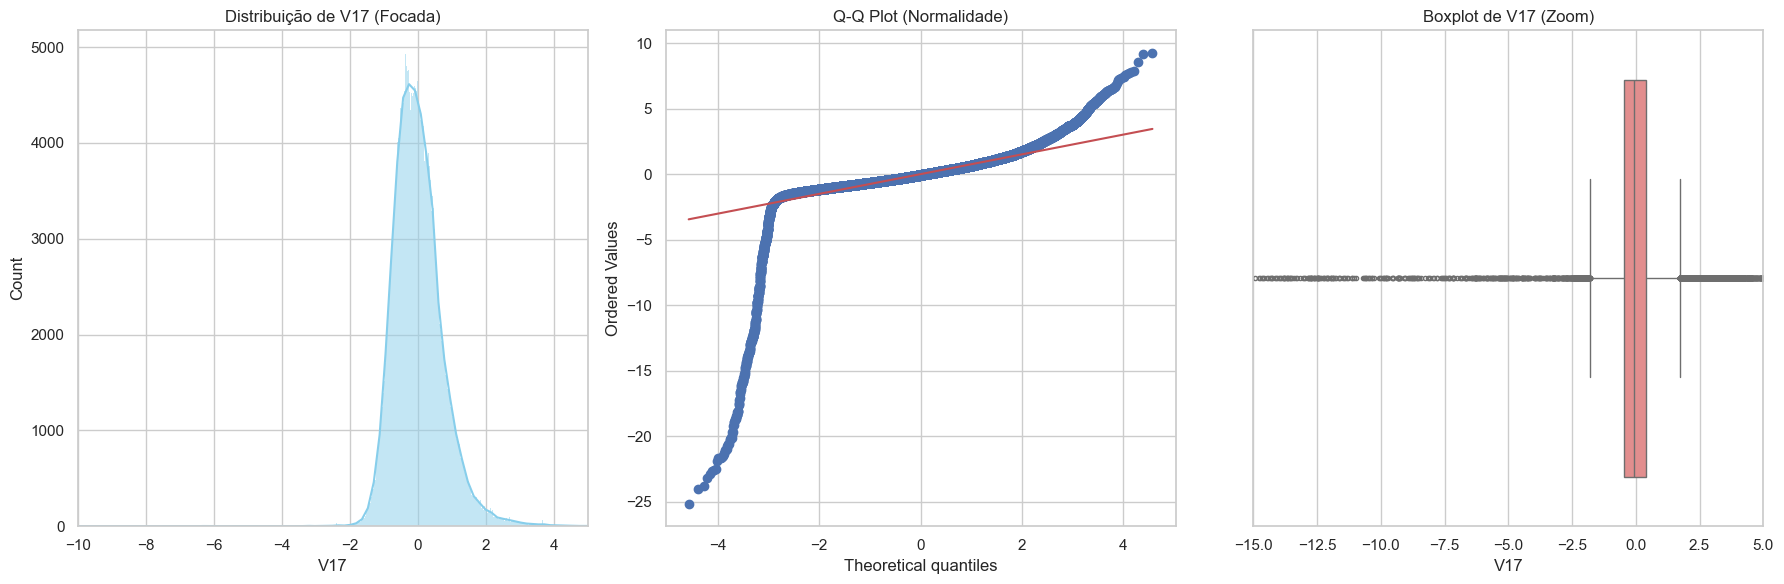

In [377]:
# selecao da feature
feature = 'V17' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V17 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V17 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.011535 -0.064833  0.749457  284315
1             -6.665836 -5.302949  6.970618     492

[2] Índice de Separação pela mediana normalizada da V17: 6.17

[3] Feature consegue separar os grupos, com 9.219384389732435e-124 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V17 e status_fraude: -0.3265

[5] Correlação de spearman entre V17 e status_fraude: -0.0443

[6]Informação Mútua entre V17 e status_fraude: 0.0083

[7] Divergência KL (V17): 1.4128


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\2656178182.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


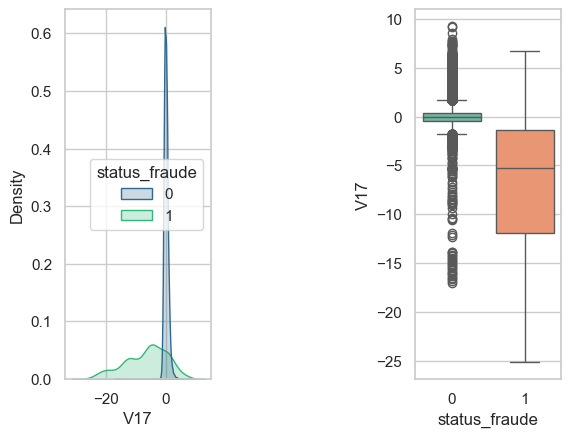

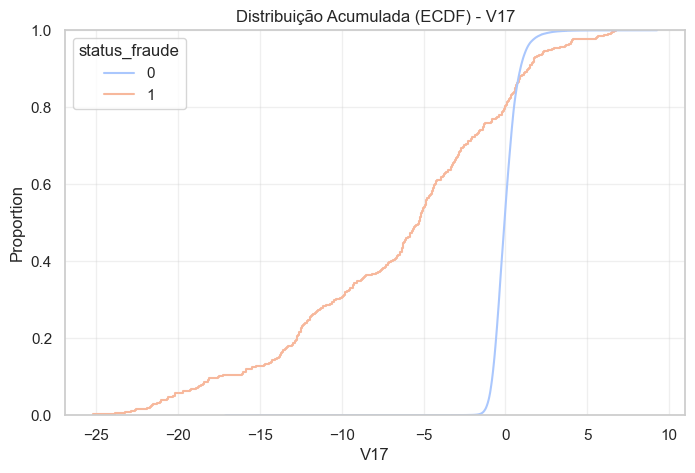

In [378]:
# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v17

In [379]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V18

#### a) V18 descritiva 

--- ANÁLISE DETALHADA: V18 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     9.564149e-16
std      8.381762e-01
min     -9.498746e+00
25%     -4.988498e-01
50%     -3.636312e-03
75%      5.008067e-01
max      5.041069e+00
Name: V18, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -0.26
Curtose (Kurtosis): 2.58

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V18: 0

[5] Entropia da feature V18: 0.9404

[6] A V18 carrega 2.29% da variabilidade total das componentes principais.

[7] A V18 possui 7533 outliers, representando um total de 2.644949035662747 %


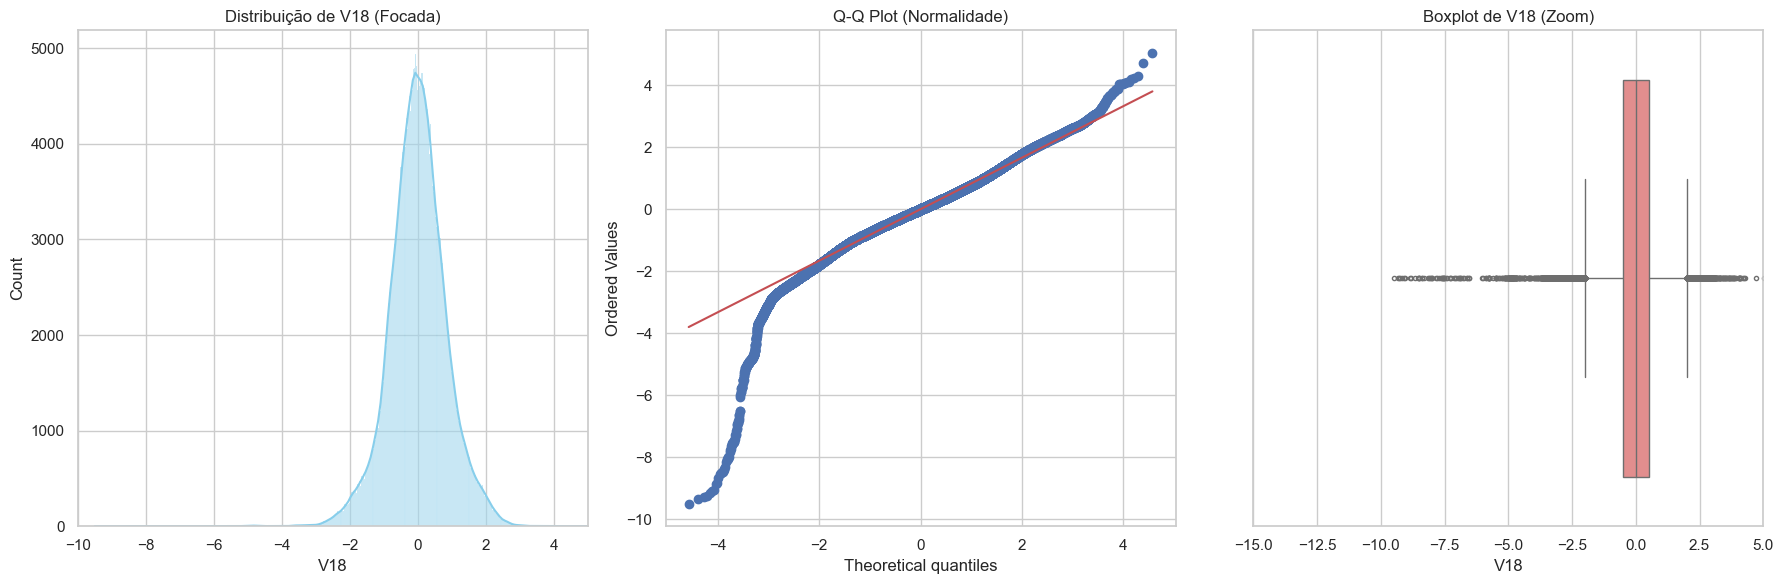

In [380]:
# selecao da feature
feature = 'V18' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V18 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V18 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.003887 -0.002787  0.824919  284315
1             -2.246308 -1.664346  2.899366     492

[2] Índice de Separação pela mediana normalizada da V18: 1.98

[3] Feature consegue separar os grupos, com 2.6489619761287066e-77 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V18 e status_fraude: -0.1115

[5] Correlação de spearman entre V18 e status_fraude: -0.0349

[6]Informação Mútua entre V18 e status_fraude: 0.0043

[7] Divergência KL (V18): 1.0265


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


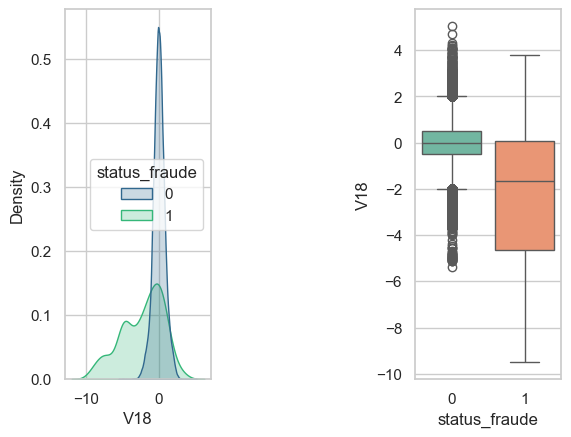

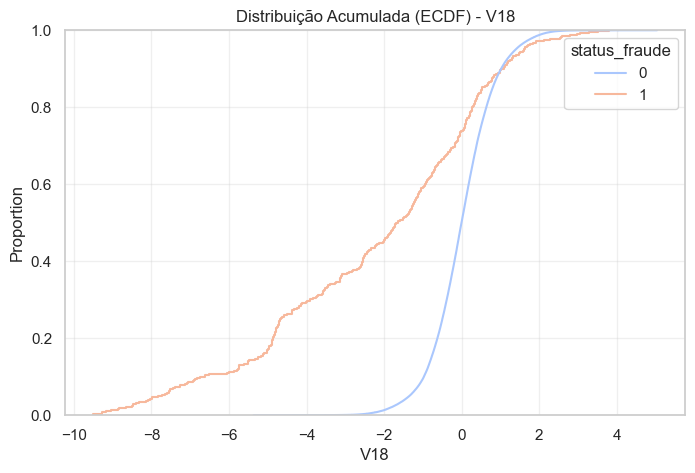

In [381]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v18

In [382]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V19

#### a) V19 descritiva 

--- ANÁLISE DETALHADA: V19 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.039917e-15
std      8.140405e-01
min     -7.213527e+00
25%     -4.562989e-01
50%      3.734823e-03
75%      4.589494e-01
max      5.591971e+00
Name: V19, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 0.11
Curtose (Kurtosis): 1.72

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V19: 0

[5] Entropia da feature V19: 1.0281

[6] A V19 carrega 2.16% da variabilidade total das componentes principais.

[7] A V19 possui 10205 outliers, representando um total de 3.5831282236742776 %


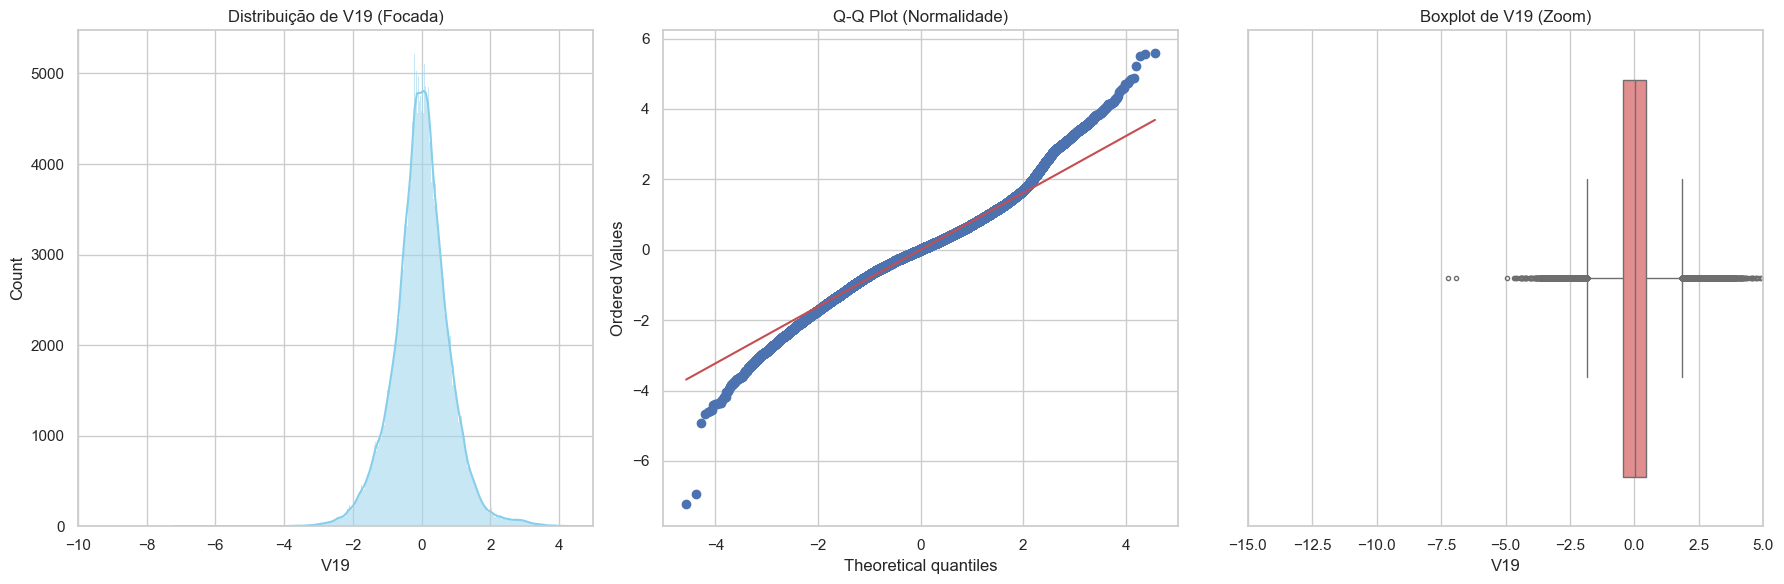

In [383]:
# selecao da feature
feature = 'V19' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V19 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V19 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.001178  0.003117  0.811733  284315
1              0.680659  0.646807  1.539853     492

[2] Índice de Separação pela mediana normalizada da V19: 0.79

[3] Feature consegue separar os grupos, com 2.4019601988224717e-33 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V19 e status_fraude: 0.0348

[5] Correlação de spearman entre V19 e status_fraude: 0.0225

[6]Informação Mútua entre V19 e status_fraude: 0.0015

[7] Divergência KL (V19): 0.7579


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


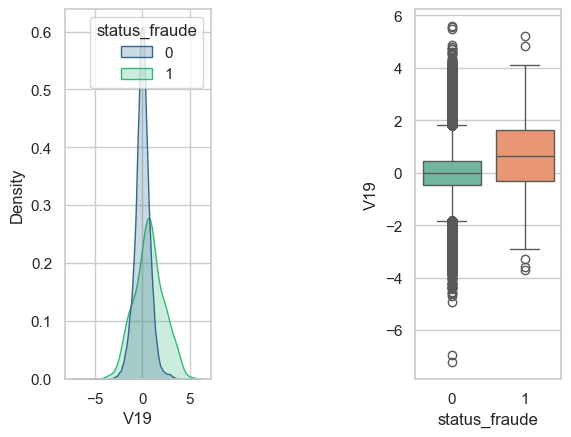

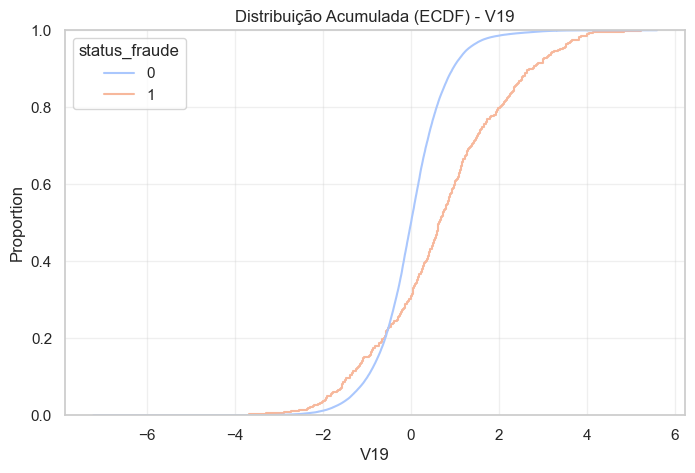

In [384]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v19

In [385]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V20

#### a) V20 descritiva 

--- ANÁLISE DETALHADA: V20 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     6.406204e-16
std      7.709250e-01
min     -5.449772e+01
25%     -2.117214e-01
50%     -6.248109e-02
75%      1.330408e-01
max      3.942090e+01
Name: V20, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -2.04
Curtose (Kurtosis): 271.02

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V20: 0

[5] Entropia da feature V20: 0.0900

[6] A V20 carrega 1.93% da variabilidade total das componentes principais.

[7] A V20 possui 27770 outliers, representando um total de 9.750462593967143 %


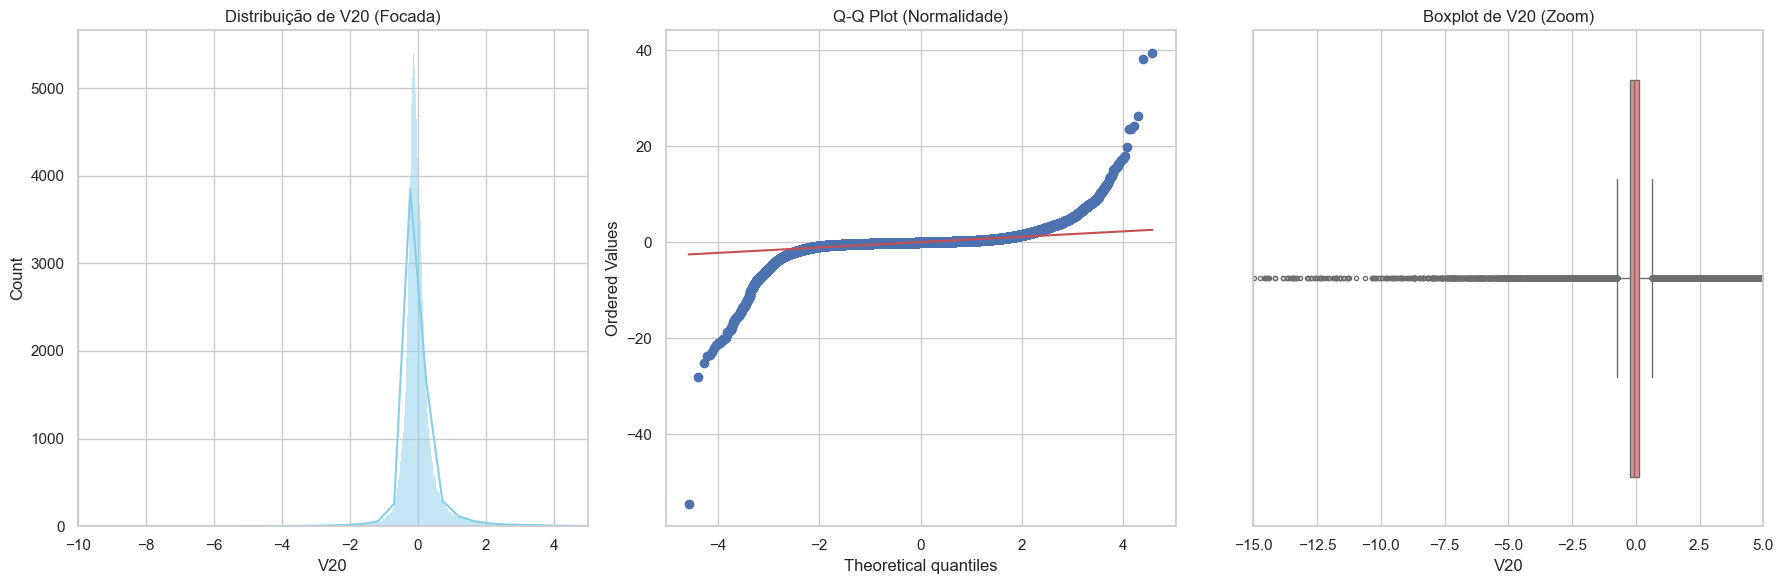

In [386]:
# selecao da feature
feature = 'V20' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V20 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V20 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000644 -0.062646  0.769404  284315
1              0.372319  0.284693  1.346635     492

[2] Índice de Separação pela mediana normalizada da V20: 0.45

[3] Feature consegue separar os grupos, com 1.1281043187424568e-30 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V20 e status_fraude: 0.0201

[5] Correlação de spearman entre V20 e status_fraude: 0.0216

[6]Informação Mútua entre V20 e status_fraude: 0.0012

[7] Divergência KL (V20): 23.2569


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


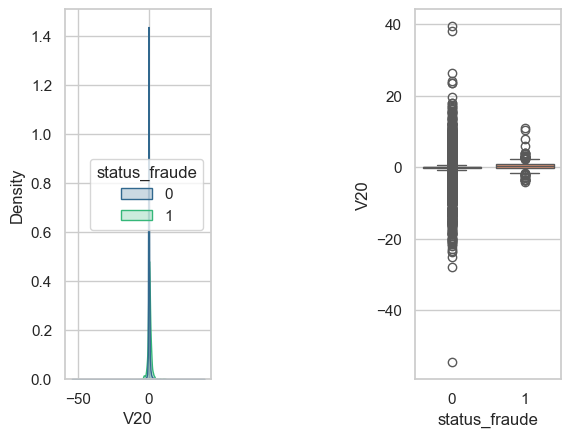

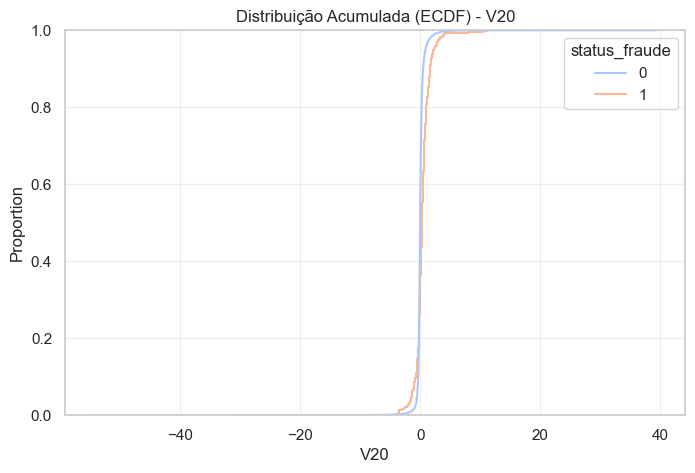

In [387]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v20

In [388]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V21

#### a) V21 descritiva 

--- ANÁLISE DETALHADA: V21 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.654067e-16
std      7.345240e-01
min     -3.483038e+01
25%     -2.283949e-01
50%     -2.945017e-02
75%      1.863772e-01
max      2.720284e+01
Name: V21, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 3.59
Curtose (Kurtosis): 207.29

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V21: 0

[5] Entropia da feature V21: 0.0636

[6] A V21 carrega 1.76% da variabilidade total das componentes principais.

[7] A V21 possui 14497 outliers, representando um total de 5.090113655914355 %


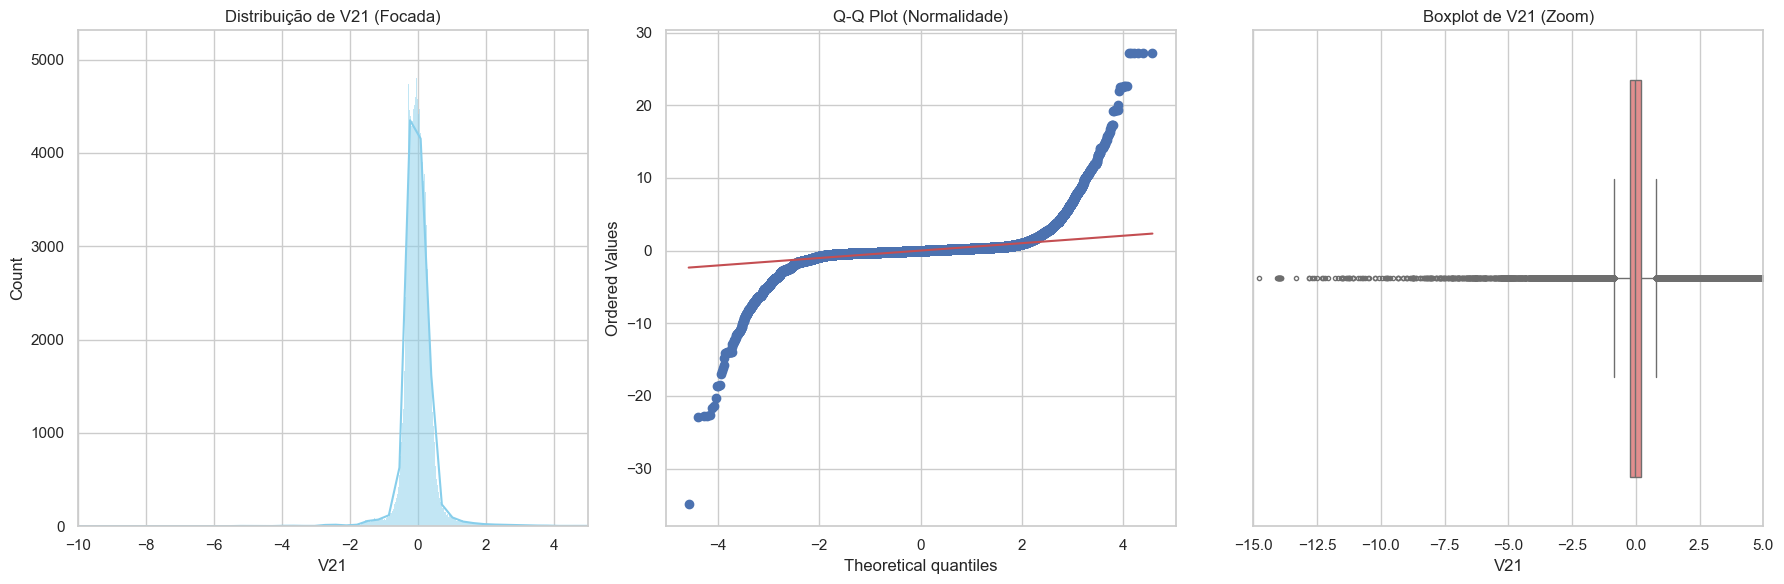

In [389]:
# selecao da feature
feature = 'V21' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V21 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V21 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.001235 -0.029821  0.716743  284315
1              0.713588  0.592146  3.869304     492

[2] Índice de Separação pela mediana normalizada da V21: 0.85

[3] Feature consegue separar os grupos, com 8.673354819194582e-80 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V21 e status_fraude: 0.0404

[5] Correlação de spearman entre V21 e status_fraude: 0.0354

[6]Informação Mútua entre V21 e status_fraude: 0.0025

[7] Divergência KL (V21): 20.3844


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


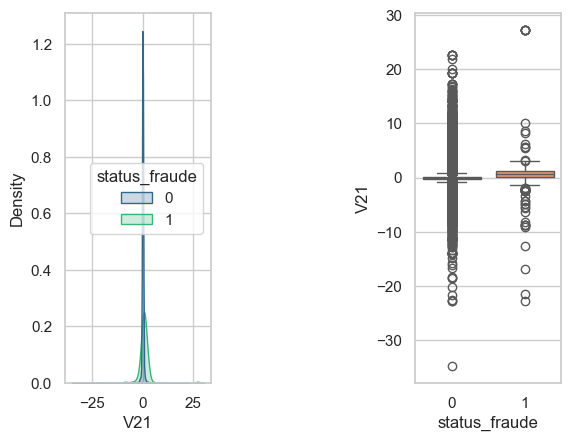

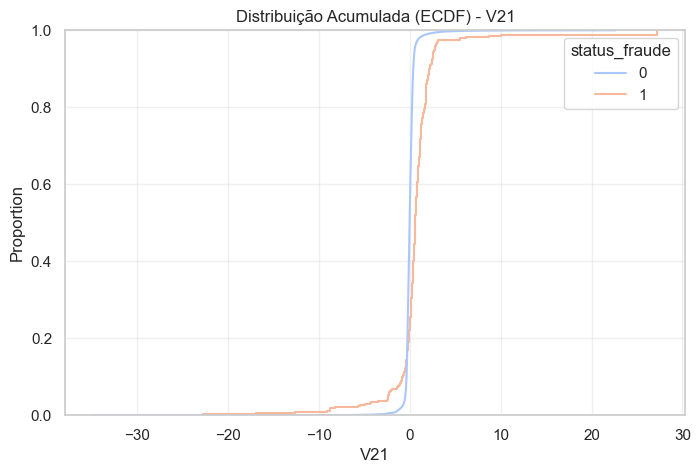

In [390]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v21

In [391]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V22

#### a) V22 descritiva 

--- ANÁLISE DETALHADA: V22 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -3.568593e-16
std      7.257016e-01
min     -1.093314e+01
25%     -5.423504e-01
50%      6.781943e-03
75%      5.285536e-01
max      1.050309e+01
Name: V22, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -0.21
Curtose (Kurtosis): 2.83

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V22: 0

[5] Entropia da feature V22: 0.7029

[6] A V22 carrega 1.71% da variabilidade total das componentes principais.

[7] A V22 possui 1317 outliers, representando um total de 0.4624184096598749 %


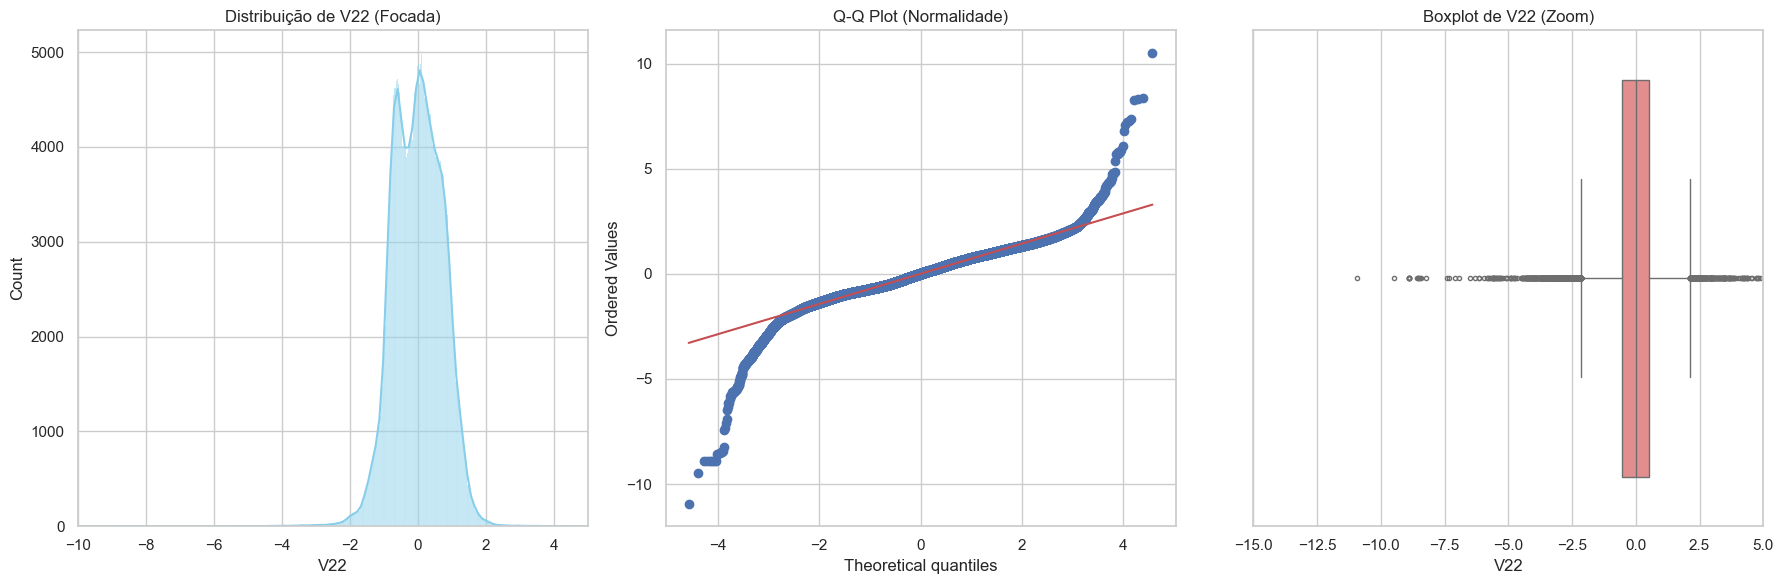

In [392]:
# selecao da feature
feature = 'V22' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V22 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V22 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000024  0.006736  0.723668  284315
1              0.014049  0.048434  1.494602     492

[2] Índice de Separação pela mediana normalizada da V22: 0.06

[3] feature não consegue separar os grupos, com 0.2663946500234552 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V22 e status_fraude: 0.0008

[5] Correlação de spearman entre V22 e status_fraude: 0.0021

[6]Informação Mútua entre V22 e status_fraude: 0.0004

[7] Divergência KL (V22): 0.1557


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


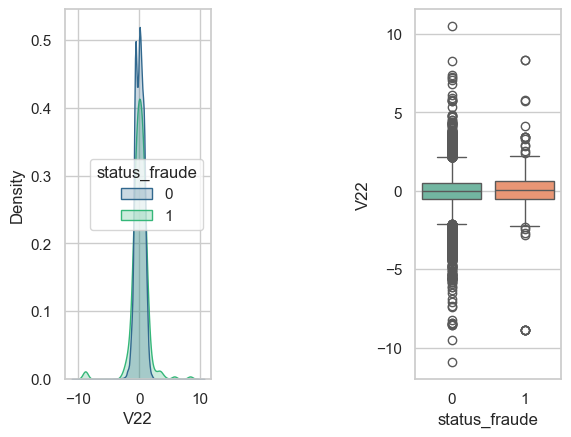

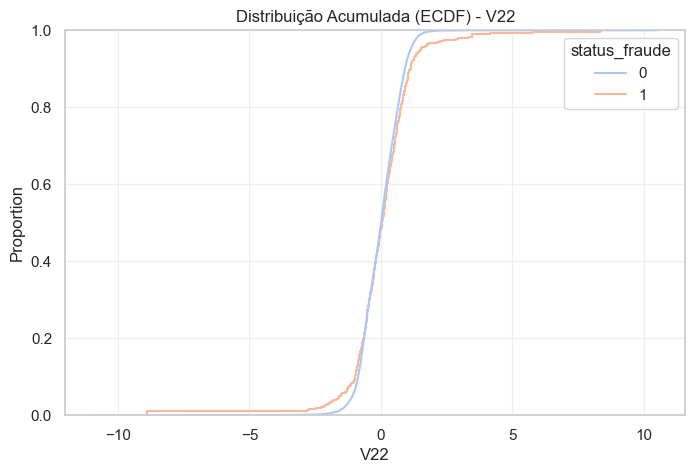

In [393]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v22

In [394]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V23

#### a) V23 descritiva 

--- ANÁLISE DETALHADA: V23 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     2.578648e-16
std      6.244603e-01
min     -4.480774e+01
25%     -1.618463e-01
50%     -1.119293e-02
75%      1.476421e-01
max      2.252841e+01
Name: V23, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -5.88
Curtose (Kurtosis): 440.09

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V23: 0

[5] Entropia da feature V23: 0.0409

[6] A V23 carrega 1.27% da variabilidade total das componentes principais.

[7] A V23 possui 18541 outliers, representando um total de 6.510022576692287 %


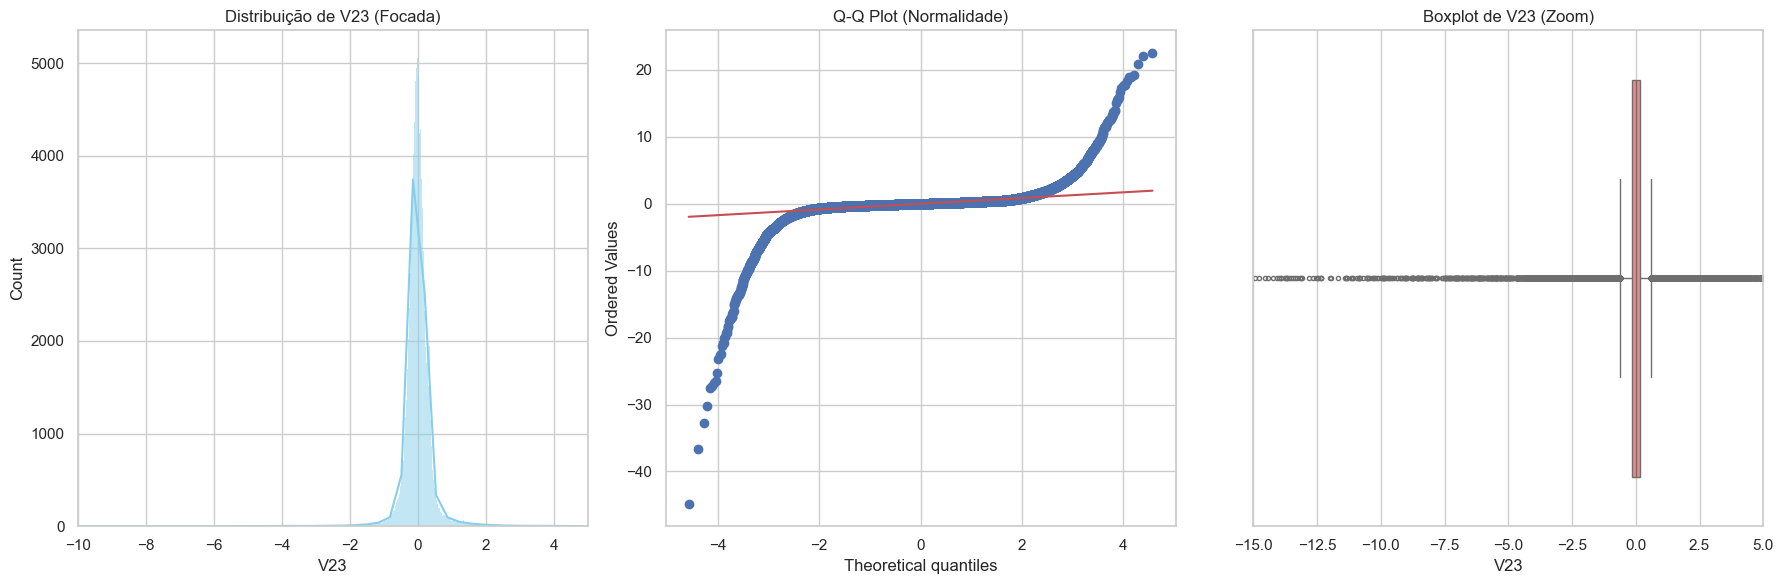

In [395]:
# selecao da feature
feature = 'V23' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V23 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V23 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.000070 -0.011147  0.621541  284315
1             -0.040308 -0.073135  1.579642     492

[2] Índice de Separação pela mediana normalizada da V23: 0.10

[3] Feature consegue separar os grupos, com 0.007419608511627531 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V23 e status_fraude: -0.0027

[5] Correlação de spearman entre V23 e status_fraude: -0.0050

[6]Informação Mútua entre V23 e status_fraude: 0.0008

[7] Divergência KL (V23): 21.5244


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


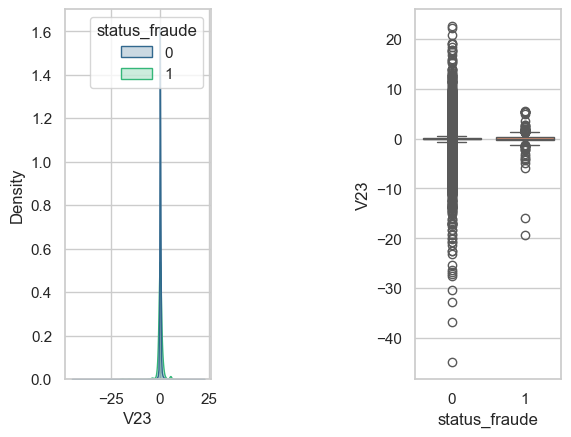

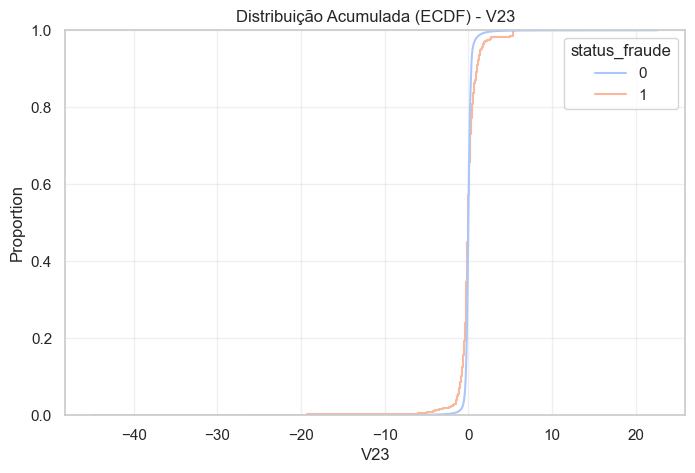

In [396]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v23

In [397]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V24

#### a) V24 descritiva 

--- ANÁLISE DETALHADA: V24 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     4.473266e-15
std      6.056471e-01
min     -2.836627e+00
25%     -3.545861e-01
50%      4.097606e-02
75%      4.395266e-01
max      4.584549e+00
Name: V24, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -0.55
Curtose (Kurtosis): 0.62

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V24: 0

[5] Entropia da feature V24: 1.2413

[6] A V24 carrega 1.19% da variabilidade total das componentes principais.

[7] A V24 possui 4774 outliers, representando um total de 1.67622284564635 %


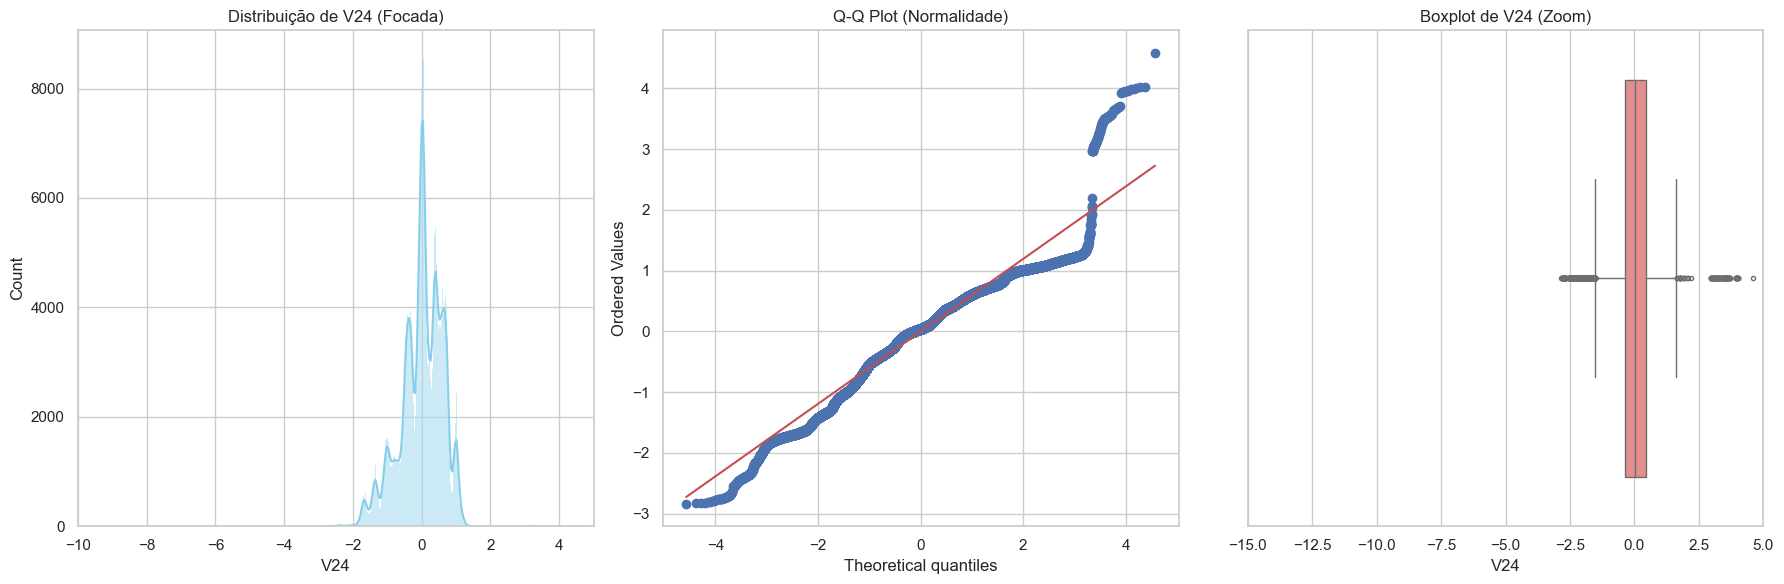

In [398]:
# selecao da feature
feature = 'V24' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V24 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V24 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0              0.000182  0.041082  0.605776  284315
1             -0.105130 -0.060795  0.515577     492

[2] Índice de Separação pela mediana normalizada da V24: 0.17

[3] Feature consegue separar os grupos, com 9.423065514108417e-07 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V24 e status_fraude: -0.0072

[5] Correlação de spearman entre V24 e status_fraude: -0.0092

[6]Informação Mútua entre V24 e status_fraude: 0.0006

[7] Divergência KL (V24): 3.0831


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


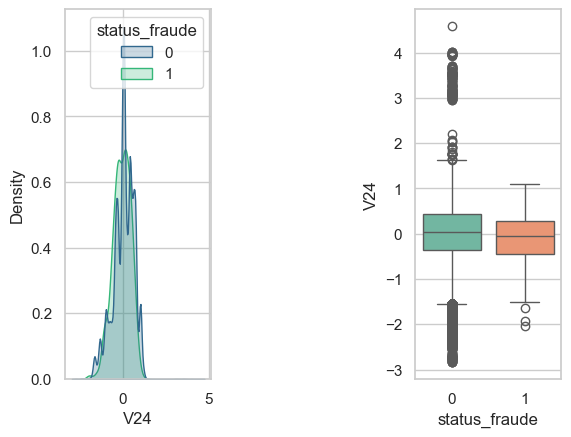

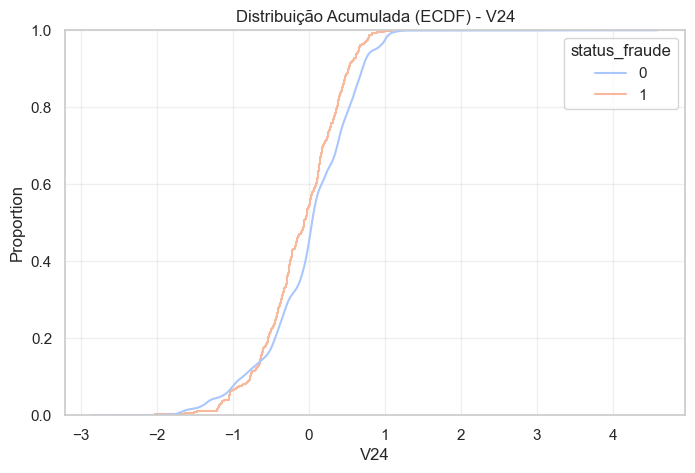

In [399]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v24

In [400]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V25

#### a) V25 descritiva 

--- ANÁLISE DETALHADA: V25 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     5.340915e-16
std      5.212781e-01
min     -1.029540e+01
25%     -3.171451e-01
50%      1.659350e-02
75%      3.507156e-01
max      7.519589e+00
Name: V25, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -0.42
Curtose (Kurtosis): 4.29

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V25: 0

[5] Entropia da feature V25: 0.5856

[6] A V25 carrega 0.88% da variabilidade total das componentes principais.

[7] A V25 possui 5367 outliers, representando um total de 1.8844340202312442 %


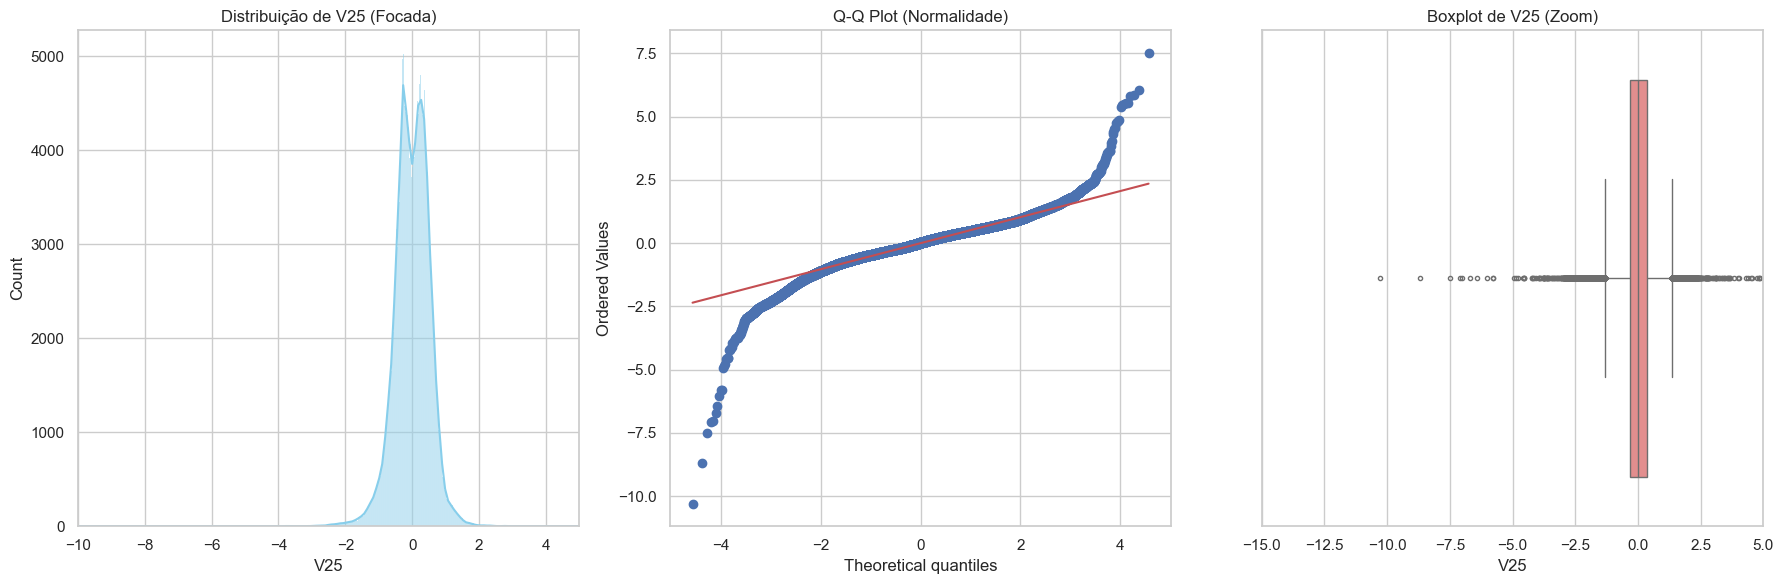

In [401]:
# selecao da feature
feature = 'V25' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V25 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V25 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000072  0.016417  0.520673  284315
1              0.041449  0.088371  0.797205     492

[2] Índice de Separação pela mediana normalizada da V25: 0.14

[3] Feature consegue separar os grupos, com 0.012462926236338216 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V25 e status_fraude: 0.0033

[5] Correlação de spearman entre V25 e status_fraude: 0.0047

[6]Informação Mútua entre V25 e status_fraude: 0.0005

[7] Divergência KL (V25): 1.8361


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


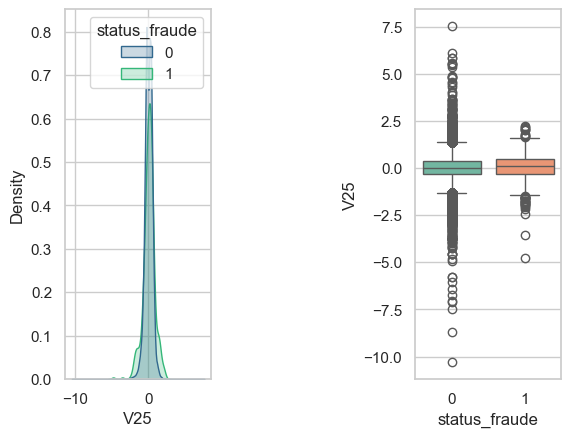

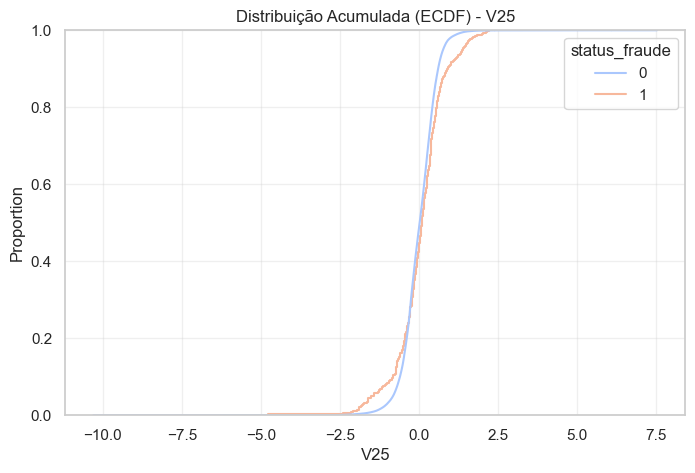

In [402]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v25

In [403]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V26

#### a) V26 descritiva 

--- ANÁLISE DETALHADA: V26 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean     1.683437e-15
std      4.822270e-01
min     -2.604551e+00
25%     -3.269839e-01
50%     -5.213911e-02
75%      2.409522e-01
max      3.517346e+00
Name: V26, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 0.58
Curtose (Kurtosis): 0.92

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V26: 0

[5] Entropia da feature V26: 1.2217

[6] A V26 carrega 0.76% da variabilidade total das componentes principais.

[7] A V26 possui 5596 outliers, representando um total de 1.9648393473475019 %


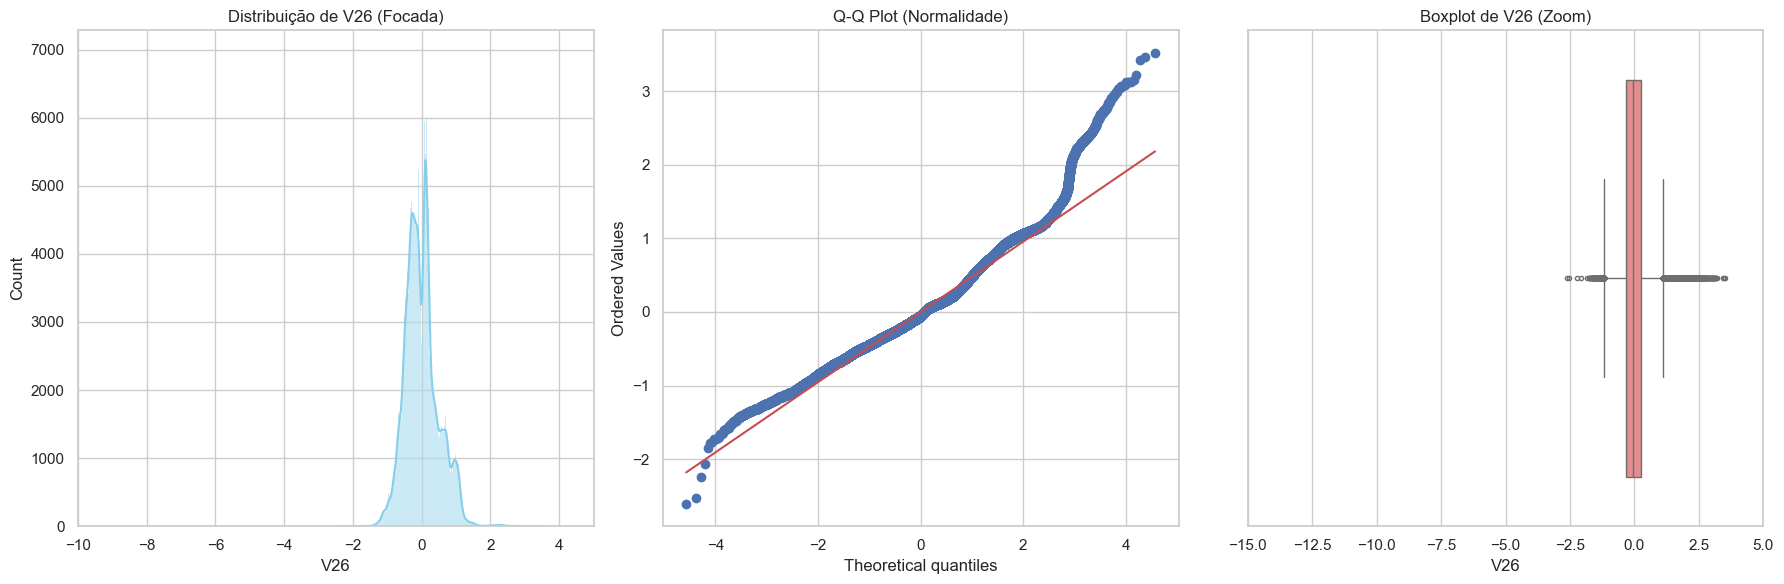

In [404]:
# selecao da feature
feature = 'V26' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V26 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V26 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000089 -0.052227  0.482241  284315
1              0.051648  0.004321  0.471679     492

[2] Índice de Separação pela mediana normalizada da V26: 0.12

[3] Feature consegue separar os grupos, com 0.00353190452220665 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V26 e status_fraude: 0.0045

[5] Correlação de spearman entre V26 e status_fraude: 0.0055

[6]Informação Mútua entre V26 e status_fraude: 0.0005

[7] Divergência KL (V26): 0.9174


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


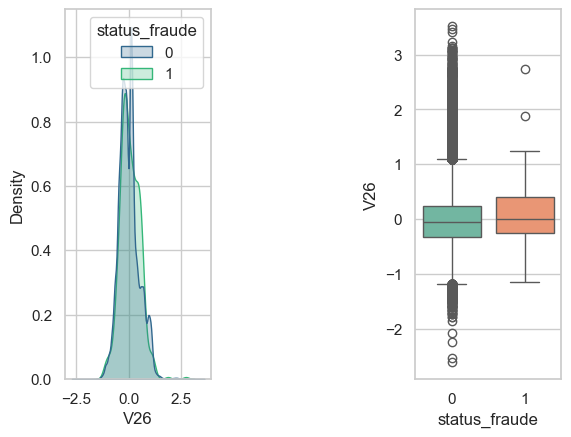

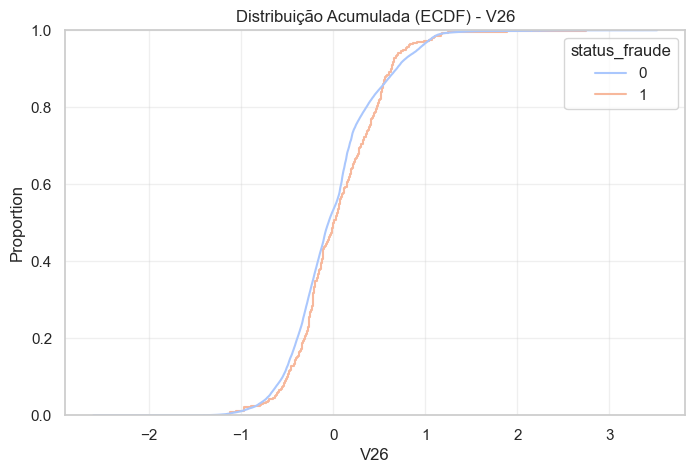

In [405]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v26

In [406]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V27

#### a) V27 descritiva 

--- ANÁLISE DETALHADA: V27 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -3.660091e-16
std      4.036325e-01
min     -2.256568e+01
25%     -7.083953e-02
50%      1.342146e-03
75%      9.104512e-02
max      3.161220e+01
Name: V27, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -1.17
Curtose (Kurtosis): 244.99

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V27: 0

[5] Entropia da feature V27: 0.0908

[6] A V27 carrega 0.53% da variabilidade total das componentes principais.

[7] A V27 possui 39163 outliers, representando um total de 13.750715396742356 %


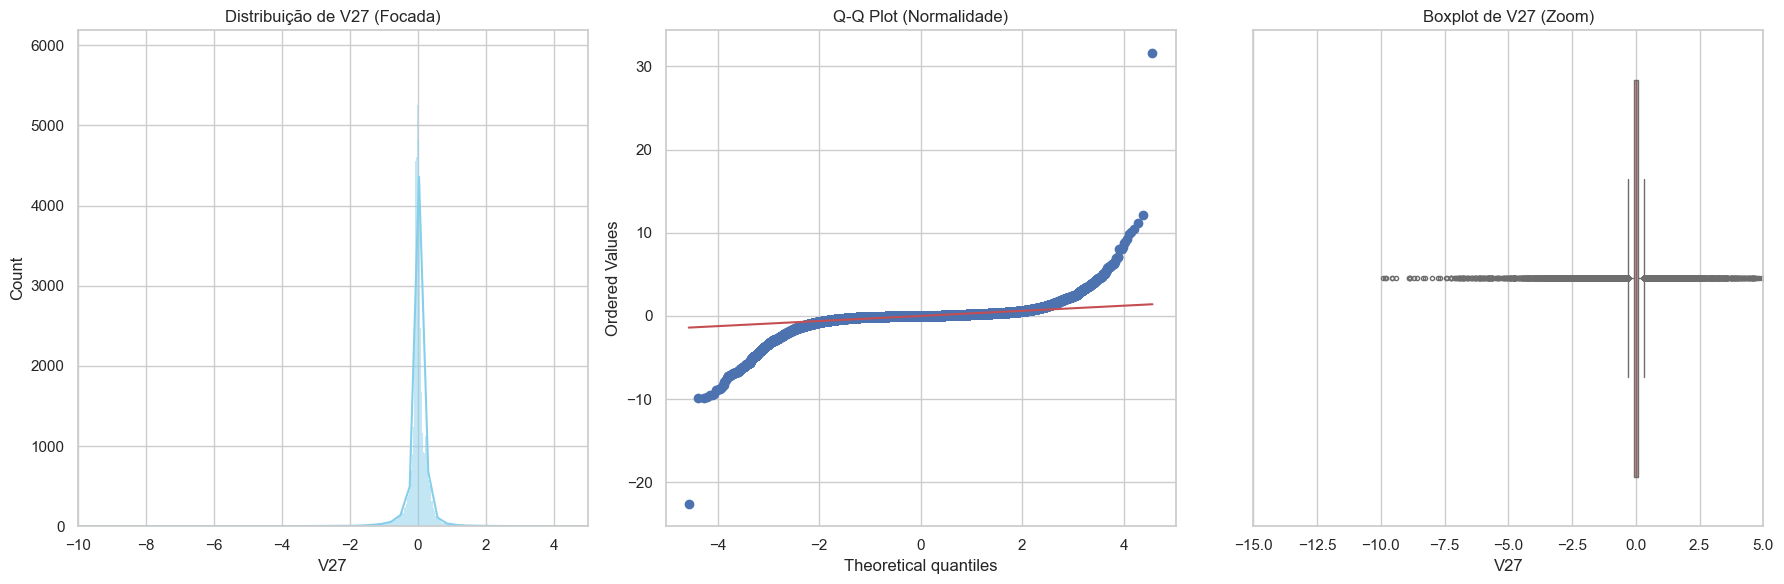

In [407]:
# selecao da feature
feature = 'V27' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V27 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V27 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000295  0.001230  0.399847  284315
1              0.170575  0.394926  1.376766     492

[2] Índice de Separação pela mediana normalizada da V27: 0.98

[3] Feature consegue separar os grupos, com 1.414589041975417e-51 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V27 e status_fraude: 0.0176

[5] Correlação de spearman entre V27 e status_fraude: 0.0283

[6]Informação Mútua entre V27 e status_fraude: 0.0024

[7] Divergência KL (V27): 7.3831


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


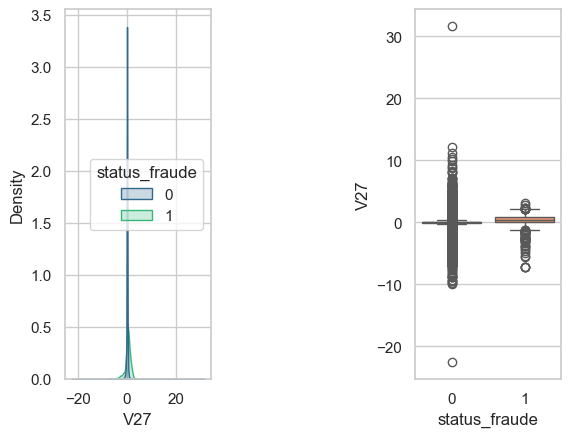

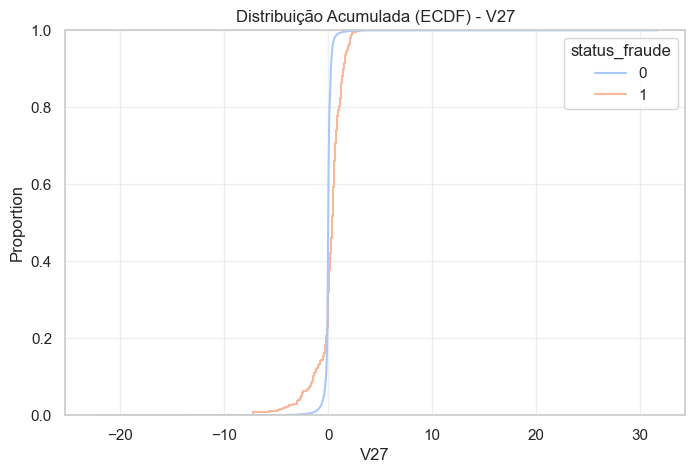

In [408]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v27

In [409]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE V28

#### a) V28 descritiva 

--- ANÁLISE DETALHADA: V28 ---

[1] Medidas Descritivas:
count    2.848070e+05
mean    -1.227390e-16
std      3.300833e-01
min     -1.543008e+01
25%     -5.295979e-02
50%      1.124383e-02
75%      7.827995e-02
max      3.384781e+01
Name: V28, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): 11.19
Curtose (Kurtosis): 933.40

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em V28: 0

[5] Entropia da feature V28: 0.0918

[6] A V28 carrega 0.35% da variabilidade total das componentes principais.

[7] A V28 possui 30342 outliers, representando um total de 10.653530285421356 %


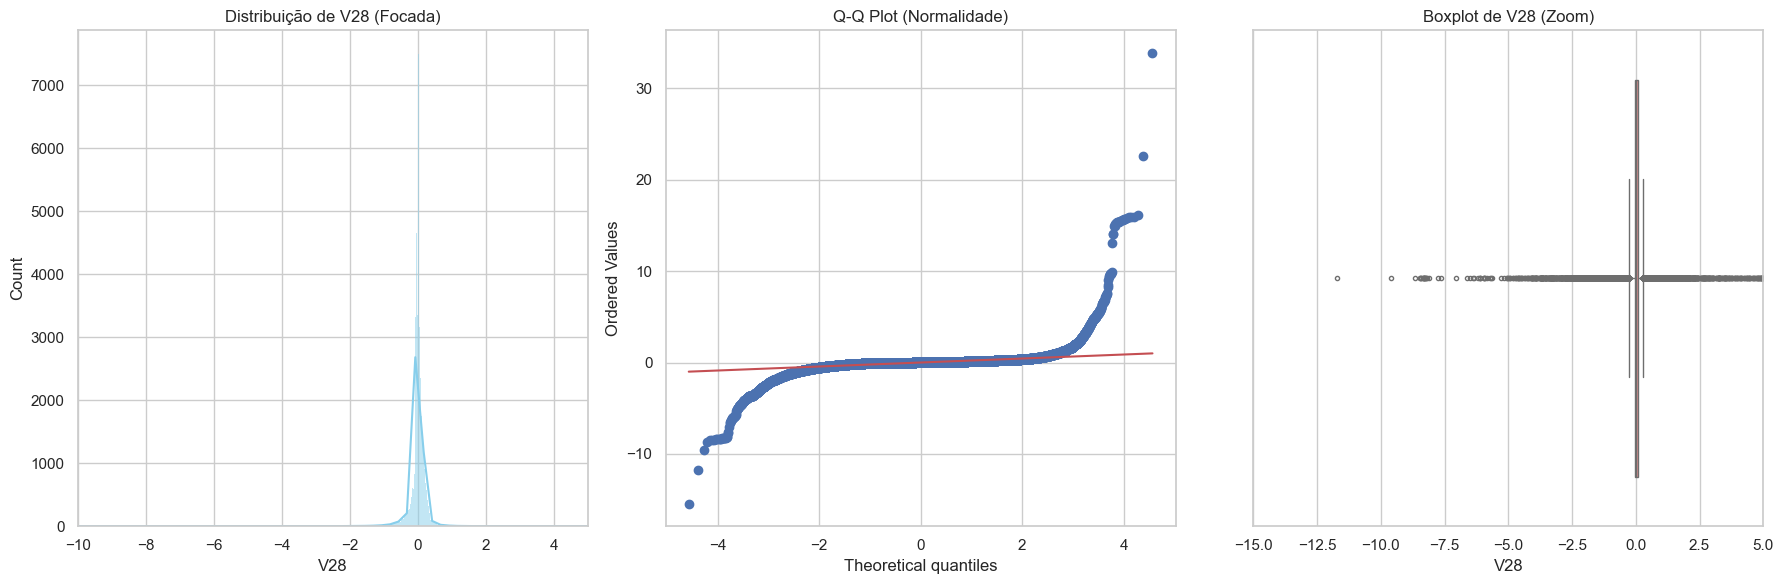

In [410]:
# selecao da feature
feature = 'V28' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = (variancias[feature] / variancia_total) * 100
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) V28 comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: V28 ---

[1] Comportamento por Classe (status_fraude):
                   mean    median       std   count
status_fraude                                      
0             -0.000131  0.011199  0.329570  284315
1              0.075667  0.146344  0.547291     492

[2] Índice de Separação pela mediana normalizada da V28: 0.41

[3] Feature consegue separar os grupos, com 1.2036828471902098e-27 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre V28 e status_fraude: 0.0095

[5] Correlação de spearman entre V28 e status_fraude: 0.0204

[6]Informação Mútua entre V28 e status_fraude: 0.0019

[7] Divergência KL (V28): 3.7996


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


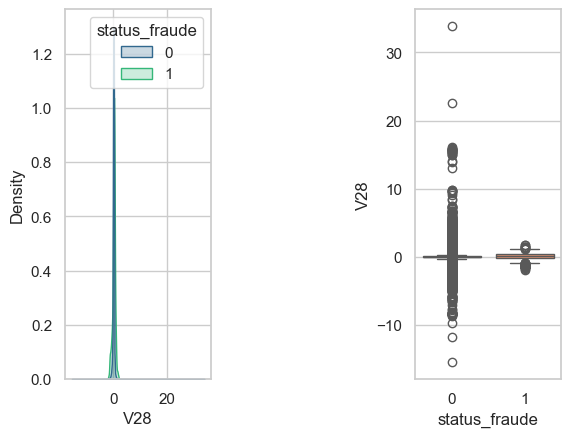

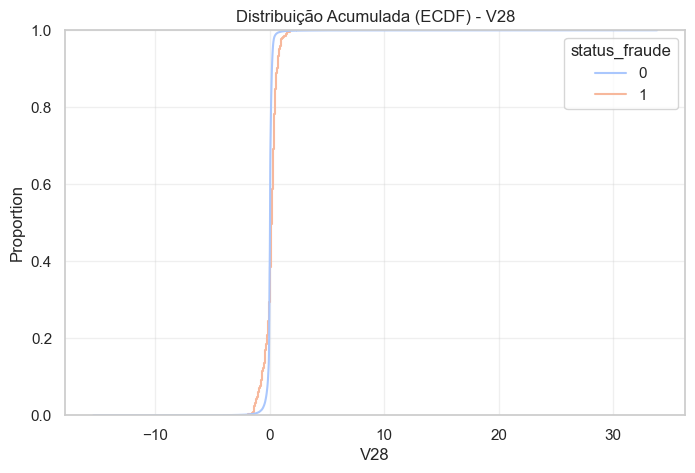

In [411]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de v28

In [412]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE tempo_desde_a_primeira_transacao

#### a) tempo_desde_a_primeira_transacao descritiva 

--- ANÁLISE DETALHADA: tempo_desde_a_primeira_transacao ---

[1] Medidas Descritivas:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: tempo_desde_a_primeira_transacao, dtype: float64

[2] Forma da Distribuição:
Assimetria (Skewness): -0.04
Curtose (Kurtosis): -1.29

[3] Os dados NÃO seguem uma distribuição normal.

[4] Dados faltantes em tempo_desde_a_primeira_transacao: 0

[5] Entropia da feature tempo_desde_a_primeira_transacao: 2.1956

[6] A tempo_desde_a_primeira_transacao carrega nan% da variabilidade total das componentes principais.

[7] A tempo_desde_a_primeira_transacao possui 0 outliers, representando um total de 0.0 %


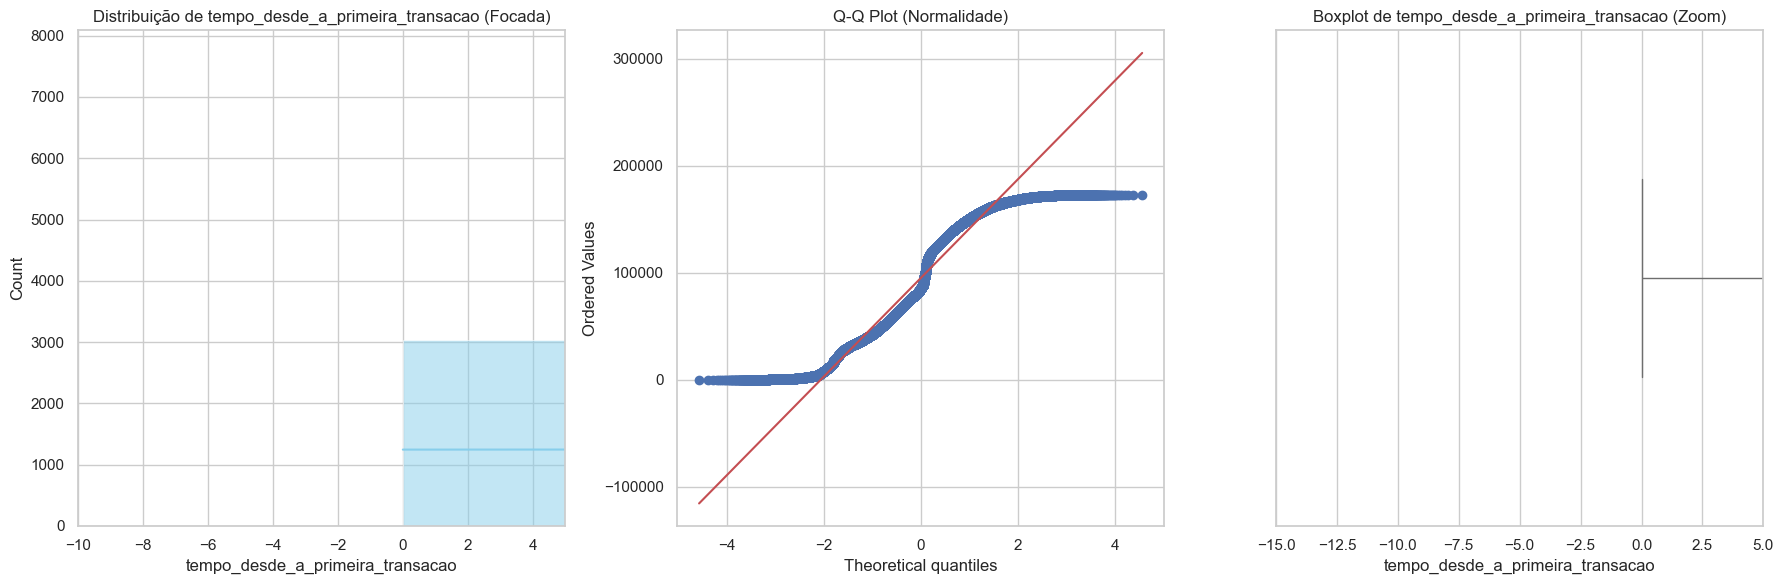

In [413]:
# selecao da feature
feature = 'tempo_desde_a_primeira_transacao' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = np.nan
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) tempo_desde_a_primeira_transacao comparada com classificacao

--- ANÁLISE DETALHADA E COMPARATIVA: tempo_desde_a_primeira_transacao ---

[1] Comportamento por Classe (status_fraude):
                       mean   median           std   count
status_fraude                                             
0              94838.202258  84711.0  47484.015786  284315
1              80746.806911  75568.5  47835.365138     492

[2] Índice de Separação pela mediana normalizada da tempo_desde_a_primeira_transacao: 0.19

[3] Feature consegue separar os grupos, com 4.386159162408272e-10 valor através do teste de Mann-Whitney U

[4] Correlação de Pearson entre tempo_desde_a_primeira_transacao e status_fraude: -0.0123

[5] Correlação de spearman entre tempo_desde_a_primeira_transacao e status_fraude: -0.0117

[6]Informação Mútua entre tempo_desde_a_primeira_transacao e status_fraude: 0.0019

[7] Divergência KL (tempo_desde_a_primeira_transacao): 0.3830


C:\Users\Vitor Craveiro\AppData\Local\Temp\ipykernel_10544\1665702686.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')


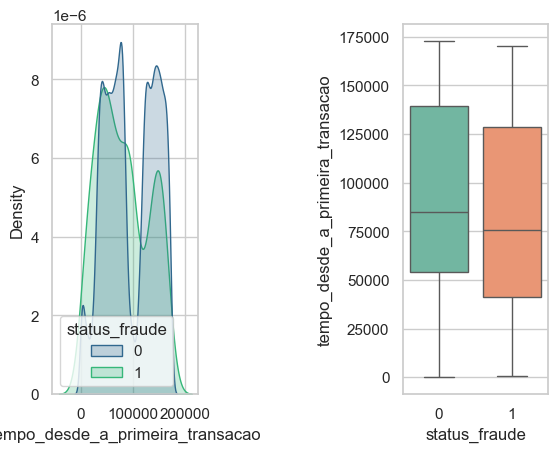

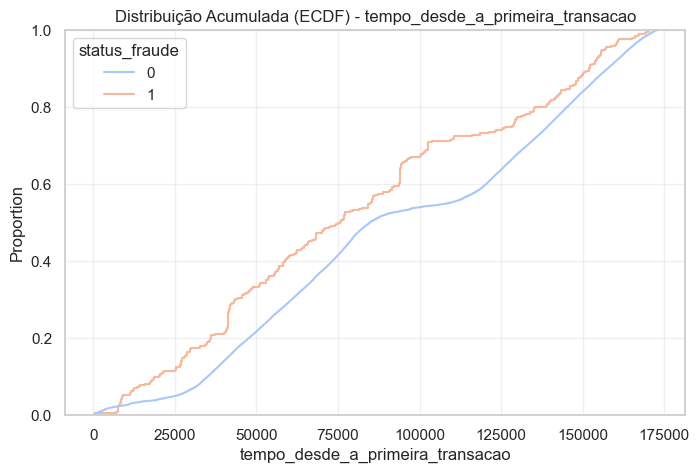

In [414]:

# Detectando o nome da coluna alvo (ajuste para o nome que aparecer no seu df.columns)
coluna_alvo = 'Class' if 'Class' in df.columns else 'status_fraude' 

print(f"--- ANÁLISE DETALHADA E COMPARATIVA: {feature} ---")

# Comparação entre Classes
print(f"\n[1] Comportamento por Classe ({coluna_alvo}):")

# Aqui usamos a variável coluna_alvo que definimos acima
comparativo = df.groupby(coluna_alvo)[feature].agg(['mean', 'median', 'std', 'count'])
print(comparativo)

mediana_normal = df[df['status_fraude'] == 0][feature].median()
mediana_fraude = df[df['status_fraude'] == 1][feature].median()
desvio_geral = df[feature].std()

separacao = abs(mediana_normal - mediana_fraude) / desvio_geral
print(f"\n[2] Índice de Separação pela mediana normalizada da {feature}: {separacao:.2f}")

# Comparando a distribuicao dos dois grupos dentro da v1 
stat, ppp = mannwhitneyu(df[df['status_fraude']==0][feature], 
                       df[df['status_fraude']==1][feature])

if ppp <= 0.05: 
    print( f"\n[3] Feature consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")
else: 
    print(f"\n[3] feature não consegue separar os grupos, com {ppp} valor através do teste de Mann-Whitney U")

# Calculando a correlação de Pearson
correlacao = df[feature].corr(df['status_fraude'], method='pearson')

print(f"\n[4] Correlação de Pearson entre {feature} e status_fraude: {correlacao:.4f}")

# Calculando a correlação de Spearman
correlacao_spearman = df[feature].corr(df['status_fraude'], method='spearman')

print(f"\n[5] Correlação de spearman entre {feature} e status_fraude: {correlacao_spearman:.4f}")

# Definindo X e y (garantindo que y seja a coluna correta)
X = df[[feature]]
y = df['status_fraude']

# O random_state garante que o resultado seja o mesmo se você rodar de novo
mi = mutual_info_classif(X, y, random_state=42)

print(f"\n[6]Informação Mútua entre {feature} e status_fraude: {mi[0]:.4f}")

# Criamos histogramas para aproximar a densidade de cada classe
p, _ = np.histogram(df[df['status_fraude'] == 0][feature], bins=50, density=True)
q, _ = np.histogram(df[df['status_fraude'] == 1][feature], bins=50, density=True)

# Adicionamos um valor minúsculo para evitar divisão por zero
p += 1e-10
q += 1e-10

kl_div = entropy(p, q)
print(f"\n[7] Divergência KL ({feature}): {kl_div:.4f}")

# gráfico
plt.subplot(1, 3, 1)
sns.kdeplot(data=df, x=feature, hue=coluna_alvo, common_norm=False, fill=True, palette='viridis')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x=coluna_alvo, y=feature, palette='Set2')

plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x=feature, hue='status_fraude', palette='coolwarm')
plt.title(f'Distribuição Acumulada (ECDF) - {feature}')
plt.grid(True, alpha=0.3)
plt.show()


#### c) Criação de dataset representativo de tempo_desde_a_primeira_transacao

In [415]:
# adicionando nova linha
nova_linha = {
    "Feature": feature,
    "Normalidade": normal,
    "Entropia": entropy_value, 
    "Var_Prop_Pca": v_info,
    "Qnd_Outliers": num_outliers,
    "Sep_mediana_norm": separacao,
    "Comparacao_dis_whith": ppp,
    "Corr_pearson": correlacao,
    "Correlacao_spearman": correlacao_spearman,
    "inf_mutua": mi[0],
    "divergencia_kl": kl_div,
}

# Adicionando à lista
resumo_features.append(nova_linha)
# Criando/Atualizando o Dataset de resumo
df_resumo = pd.DataFrame(resumo_features)
# Exibindo o resultado
display(df_resumo)

,Feature,Normalidade,Entropia,Var_Prop_Pca,Qnd_Outliers,Sep_mediana_norm,Comparacao_dis_whith,Corr_pearson,Correlacao_spearman,inf_mutua,divergencia_kl
0,V1,0,0.176718,12.483757,7062,1.206170,1.740785e-113,-0.101347,-0.042424,0.002127,1.172595
1,V2,0,0.121341,8.872945,13526,1.607088,1.650438e-163,0.091289,0.051062,0.003228,5.409018
2,V3,0,0.255065,7.480934,3363,3.467369,1.211048e-219,-0.192961,-0.059278,0.004952,1.266913
3,V4,0,1.013255,6.523148,11148,2.966061,3.625904e-248,0.133447,0.063045,0.004976,0.977064
4,V5,0,0.027485,6.199045,12295,1.064668,3.053712e-58,-0.094974,-0.030147,0.002391,3.511113
5,V6,0,0.120128,5.775592,22965,0.864308,2.231002e-93,-0.043643,-0.038410,0.002388,2.296178
6,V7,0,0.021282,4.979852,8948,2.486101,1.464234e-146,-0.187257,-0.048308,0.003952,7.288937
7,V8,0,0.145283,4.641696,24134,0.501918,8.509891e-34,0.019875,0.022706,0.001898,3.135096
8,V9,0,0.600027,3.927497,8283,1.964993,8.943723e-154,-0.097733,-0.049499,0.004277,4.391476
9,V10,0,0.658156,3.857867,9496,4.120819,9.611131e-222,-0.216883,-0.059564,0.007530,2.806436


### ESTUDO SOBRE valor_de_transacao

#### a) valor_de_transacao descritiva 

In [ ]:
# selecao da feature
feature = 'valor_de_transacao' 

print(f"--- ANÁLISE DETALHADA: {feature} ---")

# Medidas Descritivas
print(f"\n[1] Medidas Descritivas:")
print(df[feature].describe())

# Assimetria e Curtose
print(f"\n[2] Forma da Distribuição:")
print(f"Assimetria (Skewness): {df[feature].skew():.2f}")
print(f"Curtose (Kurtosis): {df[feature].kurtosis():.2f}")

# Teste de Jarque-Bera
statistic, p_value = jarque_bera(df[feature].dropna())
alpha = 0.05

normal = 1 
if p_value > alpha:
    print(f"\n[3] Os dados parecem seguir uma distribuição normal.")
    pass
else:
    print(f"\n[3] Os dados NÃO seguem uma distribuição normal.")
    normal = 0

# Dados Faltantes
vazios = df[feature].isnull().sum()
print(f"\n[4] Dados faltantes em {feature}: {vazios}")

# Calculo da entropia
counts = np.histogram(df[feature], bins=10)[0]
entropy_value = entropy(counts)
print(f"\n[5] Entropia da feature {feature}: {entropy_value:.4f}")

# Seleciona apenas as colunas resultantes do PCA (V1 a V28)
features_pca = df.loc[:, 'V1':'V28']

# Calcula a variância de cada coluna
variancias = features_pca.var()

# Calcula a variância total (soma das variâncias de todas as V's)
variancia_total = variancias.sum()

# Calcula a proporção da V1
v_info = np.nan
print(f"\n[6] A {feature} carrega {v_info:.2f}% da variabilidade total das componentes principais.")

 # Quantidade de outliers pelo método IQR
x = df[feature].dropna()

# Calcula Q1 e Q3
q1 = x.quantile(0.25)
q3 = x.quantile(0.75)

# Calcula o IQR
iqr = q3 - q1

# Limites para outliers
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Identifica outliers
outliers = x[(x < lower_bound) | (x > upper_bound)]

# Quantidade de outliers
num_outliers = len(outliers)

# Percentual de outliers
percent_outliers = (num_outliers / len(x)) * 100

print(f"\n[7] A {feature} possui {num_outliers} outliers, representando um total de {percent_outliers} %")

# Configurando o estilo e o tamanho da imagem
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

# Histograma (focado na massa de dados)
plt.subplot(1, 3, 1)
sns.histplot(df[feature], kde=True, color='skyblue')
plt.xlim(-10, 5) # <--- AJUSTE: Foca onde a maioria dos dados está
plt.title(f'Distribuição de {feature} (Focada)')

# Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df[feature], plot=plt)
plt.title('Q-Q Plot (Normalidade)')

# Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df[feature], color='lightcoral', fliersize=3)
plt.xlim(-15, 5) # 
plt.title(f'Boxplot de {feature} (Zoom)')

plt.tight_layout() 
plt.show()


#### b) tempo_desde_a_primeira_transacao comparada com classificacao

#### c) Criação de dataset representativo de valor_de_transacao